# Welcome to the Day 3 workshop:
## Prioritising SNPs for genomic prediction using plant DNA foundation models

What we're doing today:
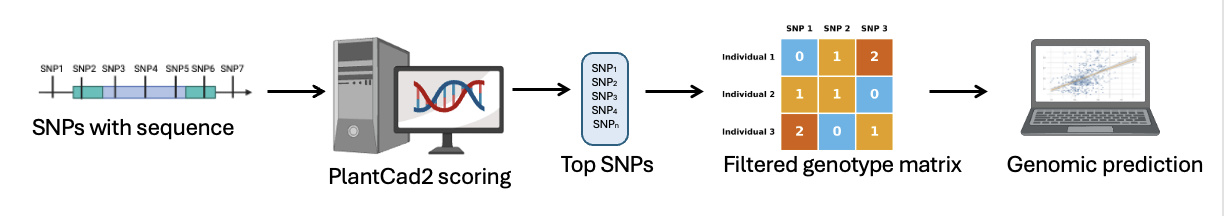

#Getting started with colab
Colab allows us to generate code directly using the Gemini.

To start, we can press the Gemini button:


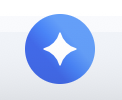

Or we can use the magic pen icon on the top right of any selected cell, then select "generate code" to prompt Gemini to work only in that specified cell.

If there's any code you'd like explain, you can  select "explain code" to prompt Gemini to describe the code in a simple, understandable way.

Try some of this out on the code block below.



---

# Loading dependencies and setting up our environment

## Uninstalling existing tools to ensure a clean setting,

These uninstall commands can be used if you notice conflict errors during installation of pytorch and mamba-ssm. Ignoring these commands will have no effect on your code. This is just to avoid conflict warning messages.

In [ ]:
!pip uninstall -y torch torchvision transformers mamba-ssm causal-conv1d sentence-transformers hdbscan xarray-einstats
!pip uninstall -y \
hdbscan umap-learn shap imbalanced-learn tsfresh \
jax jaxlib pytensor \
cuml-cu12 cupy-cuda12x \
opencv-python opencv-python-headless opencv-contrib-python \
rasterio tobler access tifffile xarray-einstats \
sentence-transformers peft transformers huggingface-hub tokenizers

## Install specific pytorch
We are installing a specific version of PyTorch (2.3.1) to resolve some errors when loading mamba-ssm, The most critical part is `--index-url https://download.pytorch.org/whl/cu121`. This command tells pip to NOT use the default repository. Instead, it downloads a special version of PyTorch that was pre-compiled specifically for systems with a CUDA 12.1 driver.

#### Why is this necessary?
Google Colab has its own system-level NVIDIA driver (e.g., CUDA 12.5). By installing a PyTorch build that is aware of a compatible CUDA version (12.1 works perfectly with a 12.5 driver), we ensure that all parts of the library, including low-level components like Triton, can find the correct drivers and compile code successfully during model inference. This fixes both the `libcuda.so` and the `ModuleNotFoundError` errors.

**WARNING: Do not add, remove or change anything within this section. mamba-ssm is very fragile in the Google Colab environment.**

In [ ]:
!pip3 install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu121 --no-build-isolation

Environment will need to restart after running the next line. This is expected.

In [ ]:
!pip3 install transformers==4.40.0 mamba-ssm==2.2.2 git+https://github.com/dridk/PyVCF3.git@master scipy==1.12.0 biopython xgboost==2.0.3 scikit-learn==1.4.0 matplotlib --no-build-isolation

In [ ]:
# causal-conv1d has installation issues at the moment. Installing mamba-ssm with transformers
# then uninstalling and reinstalling with causal-conv1d seems to be the only way to build both wheels.
!pip uninstall -y causal-conv1d mamba-ssm

!pip install causal-conv1d==1.5.0.post8 --no-build-isolation
!pip install mamba-ssm==2.2.2 --no-build-isolation

**End of fragile section. You may add, remove or edit anything after this point.**

In [ ]:
!pip install --force-reinstall --no-deps "peft==0.11.1"

# Loading the Plant Caduceus 2 model from HuggingFace 🤗

For today we are using the small version of this model. We need to ensure a few things are available first:

1.   GPU session running
2.   mamba-ssm library (needed for PlantCad2)



This is also an important validation point! If we can't load our Plant Caduceus model, it suggests our dependencies did not install correctly.

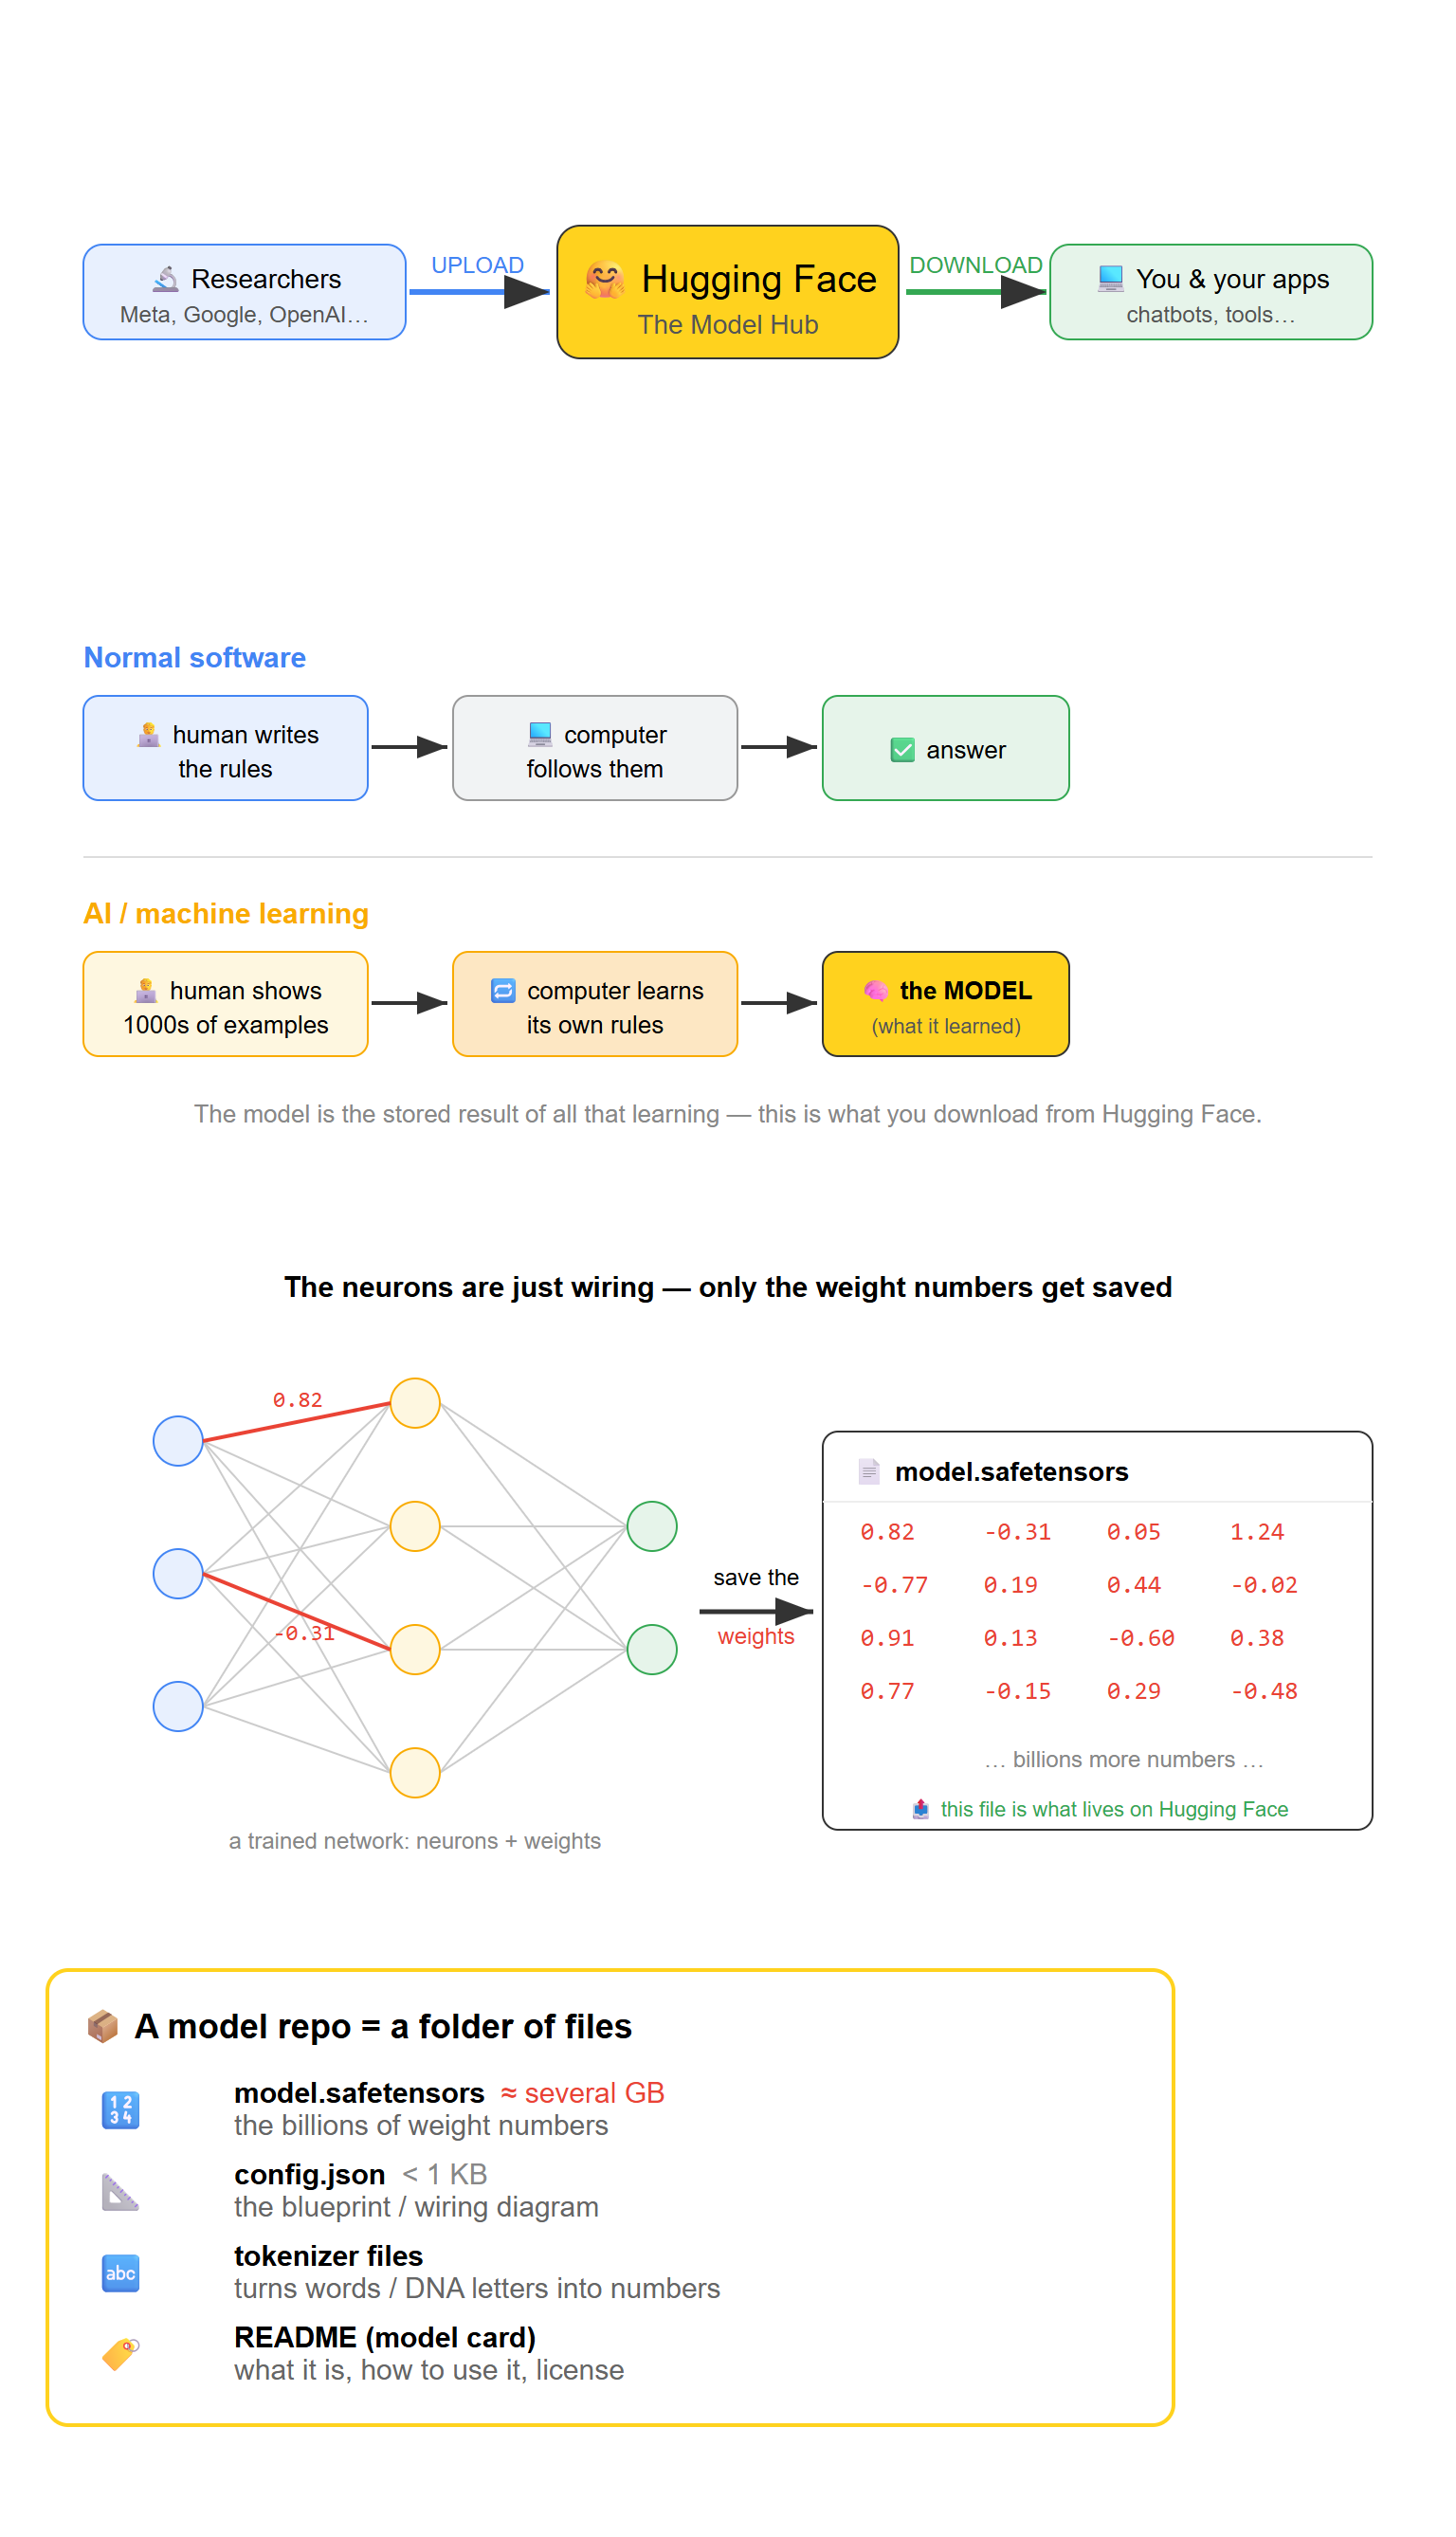

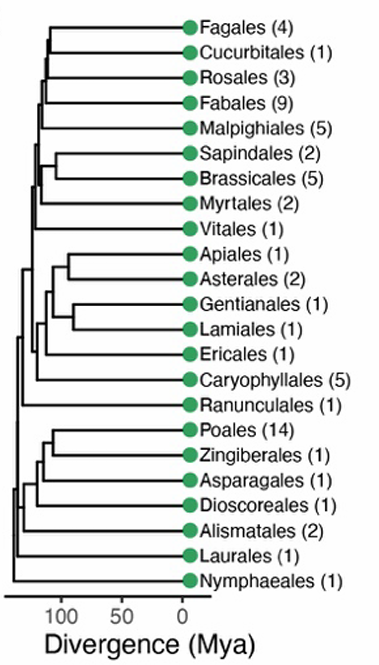

Zhai et al. (2025), bioRxiv, doi:10.1101/2025.08.27.672609

In [ ]:
import transformers
from transformers import (
    AutoModelForMaskedLM,
    AutoModelForSequenceClassification,
    AutoTokenizer,
)

!pip install peft==0.11.1
from peft import PeftModel
import torch
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "kuleshov-group/PlantCAD2-Small-l24-d0768"
expr_adapter_name = "plantcad/cross_species_leaf_absolute_expression_plantcad2_small"

# ---- Model 1: base PlantCAD2 with the MaskedLM head ----------------------
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForMaskedLM.from_pretrained(model_name, trust_remote_code=True).to(device)
model.eval()
print(f"Successfully loaded {model_name} with MaskedLM head on {device}")

# ---- Model 2: fine-tuned PlantCAD2 with an expression-regression head -----
expr_tokenizer = tokenizer
_expr_base = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=1, trust_remote_code=True
)

# The adapter_config.json was written by a newer peft and carries fields this
# transformers==4.40 / peft==0.11 stack doesn't know (e.g. 'eva_config'). We can't
# just upgrade peft: peft>=0.13 imports transformers.EncoderDecoderCache, which only
# exists in transformers>=4.43. So download the adapter, drop any config keys our
# installed LoraConfig doesn't accept, then load it from the local folder. The LoRA
# weights (and the trained 'score' head in modules_to_save) are unaffected.
import os, json, dataclasses
from huggingface_hub import snapshot_download
from peft import LoraConfig

_adapter_dir = snapshot_download(expr_adapter_name)
_cfg_path = os.path.join(_adapter_dir, "adapter_config.json")
with open(_cfg_path) as _f:
    _cfg = json.load(_f)
_valid_fields = {f.name for f in dataclasses.fields(LoraConfig)}
_removed = [k for k in list(_cfg) if k not in _valid_fields]
for k in _removed:
    _cfg.pop(k)
with open(_cfg_path, "w") as _f:
    json.dump(_cfg, _f)
if _removed:
    print(f"Stripped adapter_config keys unknown to peft {__import__('peft').__version__}: {_removed}")

expr_model = PeftModel.from_pretrained(_expr_base, _adapter_dir).to(device)
expr_model.eval()
print(f"Successfully loaded {expr_adapter_name} (expression head) on {device}")

### Download Sorghum Reference Genome
Now we will download a Sorghum reference genome.

A reference genome is constructed from many (preferably diverse) individuals in a species to give an "average snapshot" of what the species' genome should look like.

This sorghum reference genome FASTA file was obtained from Phytozome

We will download the FASTA file from GitHub directly into the local session storage. We are only using **Chromosome 9** to keep file size down for this demo



In [ ]:
# Replace the URL with your actual GitHub raw file link
genome_url = "https://github.com/dkainer/AI_WinterSchool_2026/raw/main/Sbicolor_454_v3.0.1_Chr09.fa.gz"
genome_path = "/content/sorghum_Chr09.fa.gz"

!wget -O {genome_path} {genome_url}

print(f"Finished downloading to {genome_path}")


###Download SNP data

I used Claude to extract 100 random SNPs with MAF > 0.05 from Chromosome 9 of the main VCF file. It did this in one shot using BCFtools and AWK.


**prompt:**
```
the VCF file @sap_flowering_qc.vcf contains millions of SNPs. I need a random selection of 100 SNPs from
  Chromosome 9. Each must have a minor allele frequency of at least 0.05 which can be estimated using the AC and AN info fields.
  Save the selected SNPs into a TSV table with the following columns: id, pos, ref, alt, maf
```

**output:**

```
Done. 100 SNPs saved to chr9_random100_maf05.tsv.

  Approach: bcftools view restricted to chr9 biallelic SNPs → bcftools query extracted ID/POS/REF/ALT/AC/AN → awk computed MAF =
  min(AC/AN, 1−AC/AN), filtered MAF ≥ 0.05, and tagged each row with a seeded random number → sort + head -100 performs uniform
  random sampling without replacement → header prepended.
```





In [ ]:
snps_url = "https://raw.githubusercontent.com/clairehyh99/AI_WinterSchool_2026/main/chr9_random100_maf05.tsv"
snps_path = "/content/sorghum_100_SNPs.tsv"

!wget -O {snps_path} {snps_url}

print(f"Finished downloading to {snps_path}")

In [ ]:
import pandas as pd

# Load the SNP data
df_snps = pd.read_csv(snps_path, sep='\t')

# The file uses lowercase column names: id, pos, ref, alt
snp_list = []
for _, row in df_snps.iterrows():
    snp_list.append({
        'id': str(row['id']),
        'pos': int(row['pos']),
        'ref': str(row['ref']),
        'alt': str(row['alt'])
    })

print(f"Loaded {len(snp_list)} SNPs from {snps_path}")
display(df_snps.head())

### Extract DNA sequences for each SNP
We extract the REF sequence around the SNP and also generate the ALT sequence by swapping out the variant site with the ALT allele

#### Example prompt for this script:
In this notebook I am working on a nucleotide sequence extraction from a sorghum reference genome.

Write a complete, well-commented Python script that:
- installs any required packages (eg. pysam)
- loads my reference genome, a FASTA file in /content/sorghum_Chr09.fa
- if only a gzipped FASTA exists, decompress and use this.
- I have a snp_list variable which contains my SNPs ids and their position.

Create a function that:
- extracts a sequence window centred on a SNP
- correctly convert between 1-based genomic coordinates and Python's 0-based indexing.
- Verify that the FASTA reference base matches the VCF reference allele.
- If the FASTA and VCF disagree, issue a warning and replace the FASTA base with the VCF reference allele before generating the sequence.

Generate:
- the reference sequence
- the alternate sequence containing the ALT allele at the SNP position

Return a two dictionaries containing:
- SNP ID, type (only the REF sequences), nucleotide sequence
- SNP ID, type (only the ALT sequences), nucleotide sequence

After creating this function, combine these dictionaries to create a dataframe of REF and ALT sequences. Each SNP ID should have one REF and one ALT sequence.

Print me the head of this dataframe so I can check it.

In [ ]:
!pip install pysam --no-build-isolation
import pysam
import os
import pandas as pd

# need the reference genome
genome_fasta = "/content/sorghum_Chr09.fa"
genome_path = "/content/sorghum_Chr09.fa.gz"

# 1. Decompress/Index if necessary
if os.path.exists(genome_path) and not os.path.exists(genome_fasta):
    !gunzip -c {genome_path} > {genome_fasta}
if not os.path.exists(genome_fasta + ".fai"):
    pysam.faidx(genome_fasta)

def get_snp_windows(fasta_file, chrom, pos, snp_id, ref, alt, window_size=1000):
    """
    Corrected coordinate logic for extracting REF and ALT windows.
    """
    half_window = window_size // 2
    # Genomic 'pos' is 1-based.
    # In 0-based indexing, the SNP is at pos-1.
    # Window extraction:
    start = max(0, (pos - 1) - half_window)
    end = start + window_size

    # The index of the SNP relative to the start of the fetched string:
    snp_idx_in_window = (pos - 1) - start

    with pysam.FastaFile(fasta_file) as fa:
        fasta_seq_str = fa.fetch(chrom, start, end).upper()
        fasta_seq_list = list(fasta_seq_str)

    # Safety check: Verify the reference base in the genome matches what we expect
    actual_fasta_base_at_snp = fasta_seq_list[snp_idx_in_window]
    if actual_fasta_base_at_snp != ref.upper():
        print(f"Warning for {snp_id}: expected REF {ref} at {pos}, but found {actual_fasta_base_at_snp} in FASTA. Correcting REF sequence to match VCF definition.")
        # Create the REF sequence by replacing the FASTA base with the VCF's REF allele
        ref_seq_list = fasta_seq_list.copy()
        ref_seq_list[snp_idx_in_window] = ref.upper()
    else:
        # If FASTA matches VCF REF, use the FASTA sequence directly for REF
        ref_seq_list = fasta_seq_list

    # Create ALT version by taking the (potentially corrected) REF sequence
    # and substituting the VCF's ALT allele at the SNP position.
    alt_seq_list = ref_seq_list.copy()
    alt_seq_list[snp_idx_in_window] = alt.upper()

    return [
        {"snp_id": snp_id, "type": "REF", "sequence": "".join(ref_seq_list)},
        {"snp_id": snp_id, "type": "ALT", "sequence": "".join(alt_seq_list)}
    ]


results = []
for snp in snp_list:
    results.extend(get_snp_windows(genome_fasta, "Chr09", snp['pos'], snp['id'], snp['ref'], snp['alt']))

df_snps = pd.DataFrame(results)
print(f"Extracted {len(df_snps)} sequences.")
display(df_snps.head())

It's important for us to check the SNP positions in our list are correctly aligned with the reference genome.

If not, we would be placing SNPs in random positions in the genome, rather than where they exist.

The below script checks the nucleotide left and right of each SNP, to ensure it's in the correct setting, as well as double-checking if this is a REF or ALT sequence.

In [ ]:
from collections import Counter
diag = Counter()
with pysam.FastaFile(genome_fasta) as fa:
    for snp in snp_list:
        p = snp['pos'] - 1
        base   = fa.fetch("Chr09", p,   p+1).upper()
        left   = fa.fetch("Chr09", p-1, p).upper()
        right  = fa.fetch("Chr09", p+1, p+2).upper()
        r, a = snp['ref'].upper(), snp['alt'].upper()
        if   base == r:                 diag['ok (ref matches)'] += 1
        elif base == a:                 diag['found == ALT'] += 1
        elif left == r or right == r:   diag['off-by-one'] += 1
        else:                           diag['other mismatch'] += 1
print(diag)

Another important check is to ensure the REF vs ALT sequences were built correctly.

This script checks that the sequences match and that there is a single difference between the REF and the ALT at the sequence midpoint (where the SNP should be).

In [ ]:
import numpy as np

# Retrieve sequences for REAL_SNP_01 (Updated from SNP_01)
target_snp = df_snps['snp_id'].iloc[0] # Use an existing snp_id from the DataFrame
snp01_ref_seq = df_snps[(df_snps['snp_id'] == target_snp) & (df_snps['type'] == 'REF')]['sequence'].iloc[0]
snp01_alt_seq = df_snps[(df_snps['snp_id'] == target_snp) & (df_snps['type'] == 'ALT')]['sequence'].iloc[0]

# The SNP is centered in a 1000bp window
center_idx = 500

print(f"{target_snp} Comparison (Window Center):")
print(f"REF sequence segment around center: {snp01_ref_seq[center_idx-2:center_idx+3]}")
print(f"ALT sequence segment around center: {snp01_alt_seq[center_idx-2:center_idx+3]}")

# Programmatic check for all differences
differences = [i for i in range(len(snp01_ref_seq)) if snp01_ref_seq[i] != snp01_alt_seq[i]]
print(f"\nIndices where sequences differ: {differences}")
if differences:
    idx = differences[0]
    print(f"At index {idx}: REF={snp01_ref_seq[idx]}, ALT={snp01_alt_seq[idx]}")
else:
    print("WARNING: No differences found between REF and ALT sequences!")

# Scoring SNPs!

### Nucleotide Probability score

Score each SNP: Is this allele surprising or disruptive in its local DNA context?
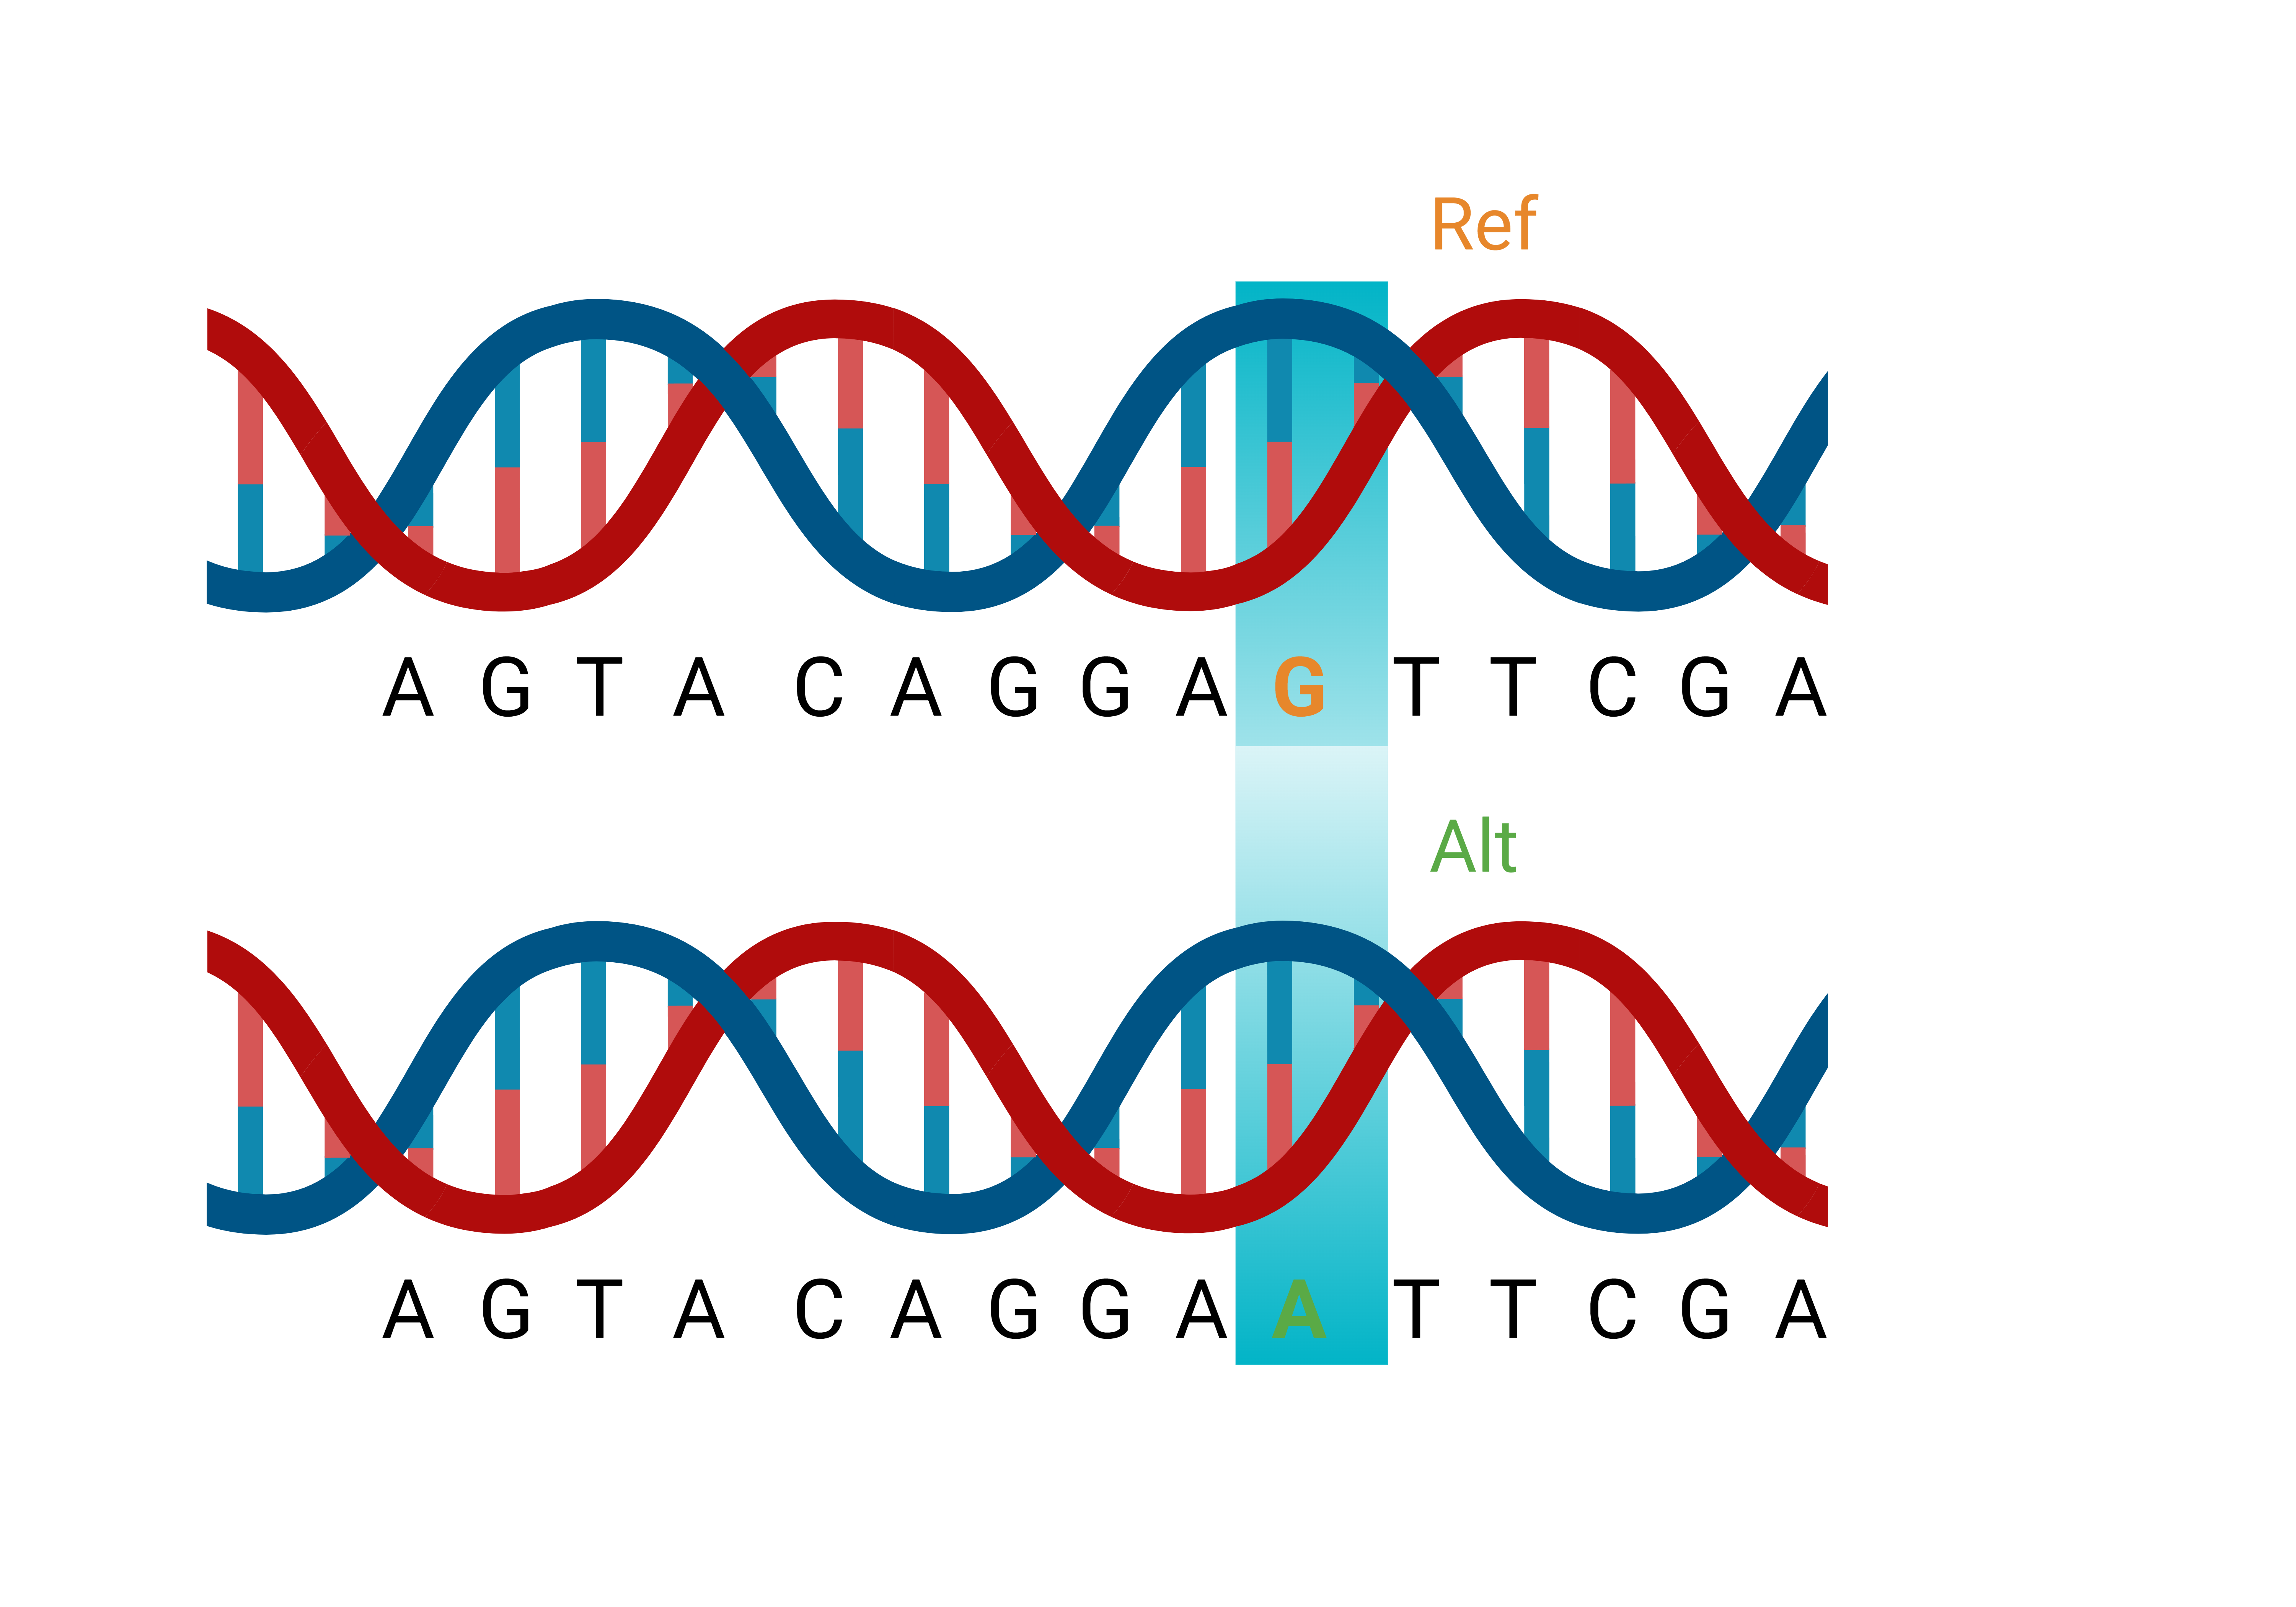



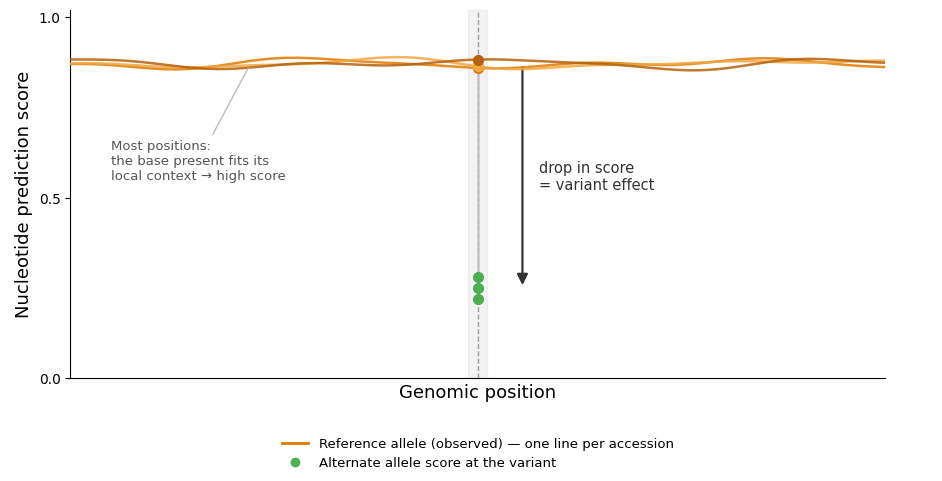

Now we will score the log likelihood of a SNP.

Remember that Plant Caduceus can predict a masked nucleotide at a given position based upon its context.

It will also determine the likelihood of each allele at this position, letting us extract the likelihoods for both the REF and ALT alleles.

By comparing the difference between the probabilities of REF and ALT alleles, we get one way of scoring a variant effect.

Very rare alleles are more likely to have significant, possibly deleterious, effects on an organism (known as purifying selection).

In [ ]:

import torch.nn.functional as F
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pysam
import os


# Check if snps_path exists. If not, instruct user to download it.
if not os.path.exists(snps_path):
    print(f"Error: SNP data file not found at {snps_path}.")
    print("Please run the 'Download SNP data' cell (cell `rZ-ofd-LepcA`) to download the necessary file.")
    raise FileNotFoundError(f"Missing required file: {snps_path}")

# First, ensure snp_list is available, which requires snps_path and initial df_snps
if 'snp_list' not in globals():
    print("Warning: 'snp_list' not found. Re-initializing from TSV.")
    df_snps_raw = pd.read_csv(snps_path, sep='\t')
    snp_list = []
    for _, row in df_snps_raw.iterrows():
        snp_list.append({
            'id': str(row['id']),
            'pos': int(row['pos']),
            'ref': str(row['ref']),
            'alt': str(row['alt'])
        })
    del df_snps_raw # Clean up temporary df
    print(f"Re-loaded {len(snp_list)} SNPs to initialize snp_list.")

# Ensure genome fasta is decompressed and indexed if needed
if not os.path.exists(genome_fasta):
    if os.path.exists(genome_path):
        print(f"Decompressing {genome_path} to {genome_fasta}...")
        !gunzip -c {genome_path} > {genome_fasta}
    else:
        print(f"Error: {genome_path} not found. Cannot extract SNP sequences. Please ensure genome is downloaded by running cell `dde5d729`.")
        raise FileNotFoundError(f"Missing required file: {genome_path}")

if os.path.exists(genome_fasta) and not os.path.exists(genome_fasta + ".fai"):
    print(f"Indexing {genome_fasta}...")
    pysam.faidx(genome_fasta)

# Define get_snp_windows function if not already defined (or redefine for robustness)
if 'get_snp_windows' not in globals():
    def get_snp_windows(fasta_file, chrom, pos, snp_id, ref, alt, window_size=1000):
        half_window = window_size // 2
        start = max(0, (pos - 1) - half_window)
        end = start + window_size
        snp_idx_in_window = (pos - 1) - start
        with pysam.FastaFile(fasta_file) as fa:
            ref_seq_str = fa.fetch(chrom, start, end).upper()
            ref_seq_list = list(ref_seq_str)
        actual_ref_base = ref_seq_list[snp_idx_in_window]
        if actual_ref_base != ref.upper():
            pass # Suppress warning for brevity in this re-initialization
        alt_seq_list = ref_seq_list.copy()
        alt_seq_list[snp_idx_in_window] = alt.upper()
        return [
            {"snp_id": snp_id, "type": "REF", "sequence": "".join(ref_seq_list)},
            {"snp_id": snp_id, "type": "ALT", "sequence": "".join(alt_seq_list)}
        ]
    print("Defined 'get_snp_windows' function.")

# Create df_snps (with sequence data) if not available or if it's the raw one lacking 'sequence' column
if 'df_snps' not in globals() or 'sequence' not in globals().get('df_snps', pd.DataFrame()).columns:
    print("Warning: 'df_snps' (with sequence data) not found. Re-extracting SNP sequences.")
    results = []
    # Using snp_list which is now guaranteed to be defined
    for snp in tqdm(snp_list, desc="Re-extracting SNP sequences"):
        results.extend(get_snp_windows(genome_fasta, "Chr09", snp['pos'], snp['id'], snp['ref'], snp['alt']))
    df_snps = pd.DataFrame(results)
    print(f"Re-extracted {len(df_snps)} sequences to create df_snps.")

# --- End of re-initialization block ---

# 1. Setup scoring logic
def get_nucleotide_probability_score(sequence, snp_idx=500, ref_base='A', alt_base='G'):
    mask_token = tokenizer.mask_token if tokenizer.mask_token else "[MASK]"
    seq_list = list(sequence)
    seq_list[snp_idx] = mask_token
    masked_sequence = "".join(seq_list)
    inputs = tokenizer(masked_sequence, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(input_ids=inputs['input_ids'])
    mask_token_id = tokenizer.mask_token_id
    token_pos = (inputs['input_ids'][0] == mask_token_id).nonzero(as_tuple=True)[0]
    idx = token_pos[0].item() if len(token_pos) > 0 else snp_idx + 1
    logits = outputs.logits[0, idx, :]
    probs = F.softmax(logits, dim=-1)
    ref_id = tokenizer.convert_tokens_to_ids(ref_base.upper())
    alt_id = tokenizer.convert_tokens_to_ids(alt_base.upper())
    if ref_id == tokenizer.unk_token_id or ref_id is None:
        ref_id = tokenizer.convert_tokens_to_ids(ref_base.lower())
    if alt_id == tokenizer.unk_token_id or alt_id is None:
        alt_id = tokenizer.convert_tokens_to_ids(alt_base.lower())
    p_ref = probs[ref_id].item()
    p_alt = probs[alt_id].item()

    # Add a small epsilon to avoid log(0)
    epsilon = 1e-9
    log_p_ref = torch.log(torch.tensor(p_ref + epsilon)).item()
    log_p_alt = torch.log(torch.tensor(p_alt + epsilon)).item()

    return abs(log_p_ref - log_p_alt), p_ref, p_alt

# Calculate probability scores for all SNPs
prob_scores_list = []
# Ensure df_snps is available and contains 'snp_id', 'type', 'sequence'
# and also 'ref', 'alt' from the original snp_list for ref_base, alt_base
# We need to iterate over unique snp_ids to get ref and alt bases once per SNP
unique_snp_ids = df_snps['snp_id'].unique()
for snp_id in tqdm(unique_snp_ids, desc="Calculating Nucleotide Probability Scores"):
    # Get the ref sequence for this snp_id
    ref_seq_row = df_snps[(df_snps['snp_id'] == snp_id) & (df_snps['type'] == 'REF')]
    if ref_seq_row.empty:
        print(f"Warning: REF sequence not found for {snp_id}. Skipping.")
        continue
    sequence = ref_seq_row['sequence'].iloc[0]

    # Find the corresponding original snp_info to get ref_base and alt_base
    snp_info = next((s for s in snp_list if s['id'] == snp_id), None)
    if snp_info is None:
        print(f"Warning: SNP info not found for {snp_id}. Skipping.")
        continue

    ref_base = snp_info['ref']
    alt_base = snp_info['alt']

    prob_score, p_ref, p_alt = get_nucleotide_probability_score(
        sequence,
        snp_idx=500, # Assuming SNP is always at center for a 1000bp window
        ref_base=ref_base,
        alt_base=alt_base
    )
    prob_scores_list.append({
        'snp_id': snp_id,
        'prob_score': prob_score,
        'p_ref': p_ref,
        'p_alt': p_alt
    })

df_prob_scores = pd.DataFrame(prob_scores_list)

# 2. Visualization of the distribution for the full dataset
print("Visualizing Nucleotide Probability distributions...")
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df_prob_scores['prob_score'], bins=50, kde=True, color='forestgreen')
plt.title('Distribution and Frequency of Nucleotide Probability Scores', fontsize=15)
plt.xlabel('Probability Score (Difference in Allele Likelihood)', fontsize=12)
plt.ylabel('Frequency (SNP Count)', fontsize=12)
plt.show()

# 3. Display top hits with full context (prob_score, p_ref, and p_alt)
print("Top 10 Hits with Allele Probabilities:")
display(df_prob_scores.sort_values(by='prob_score', ascending=False).head(10))

⬆ note the subtle differences above in the REF vs ALT embedding vectors due to the allele swap

### Embedding distance score

score = 1 - cosine( Embedding(Ref DNA), Embedding(Alt DNA) )


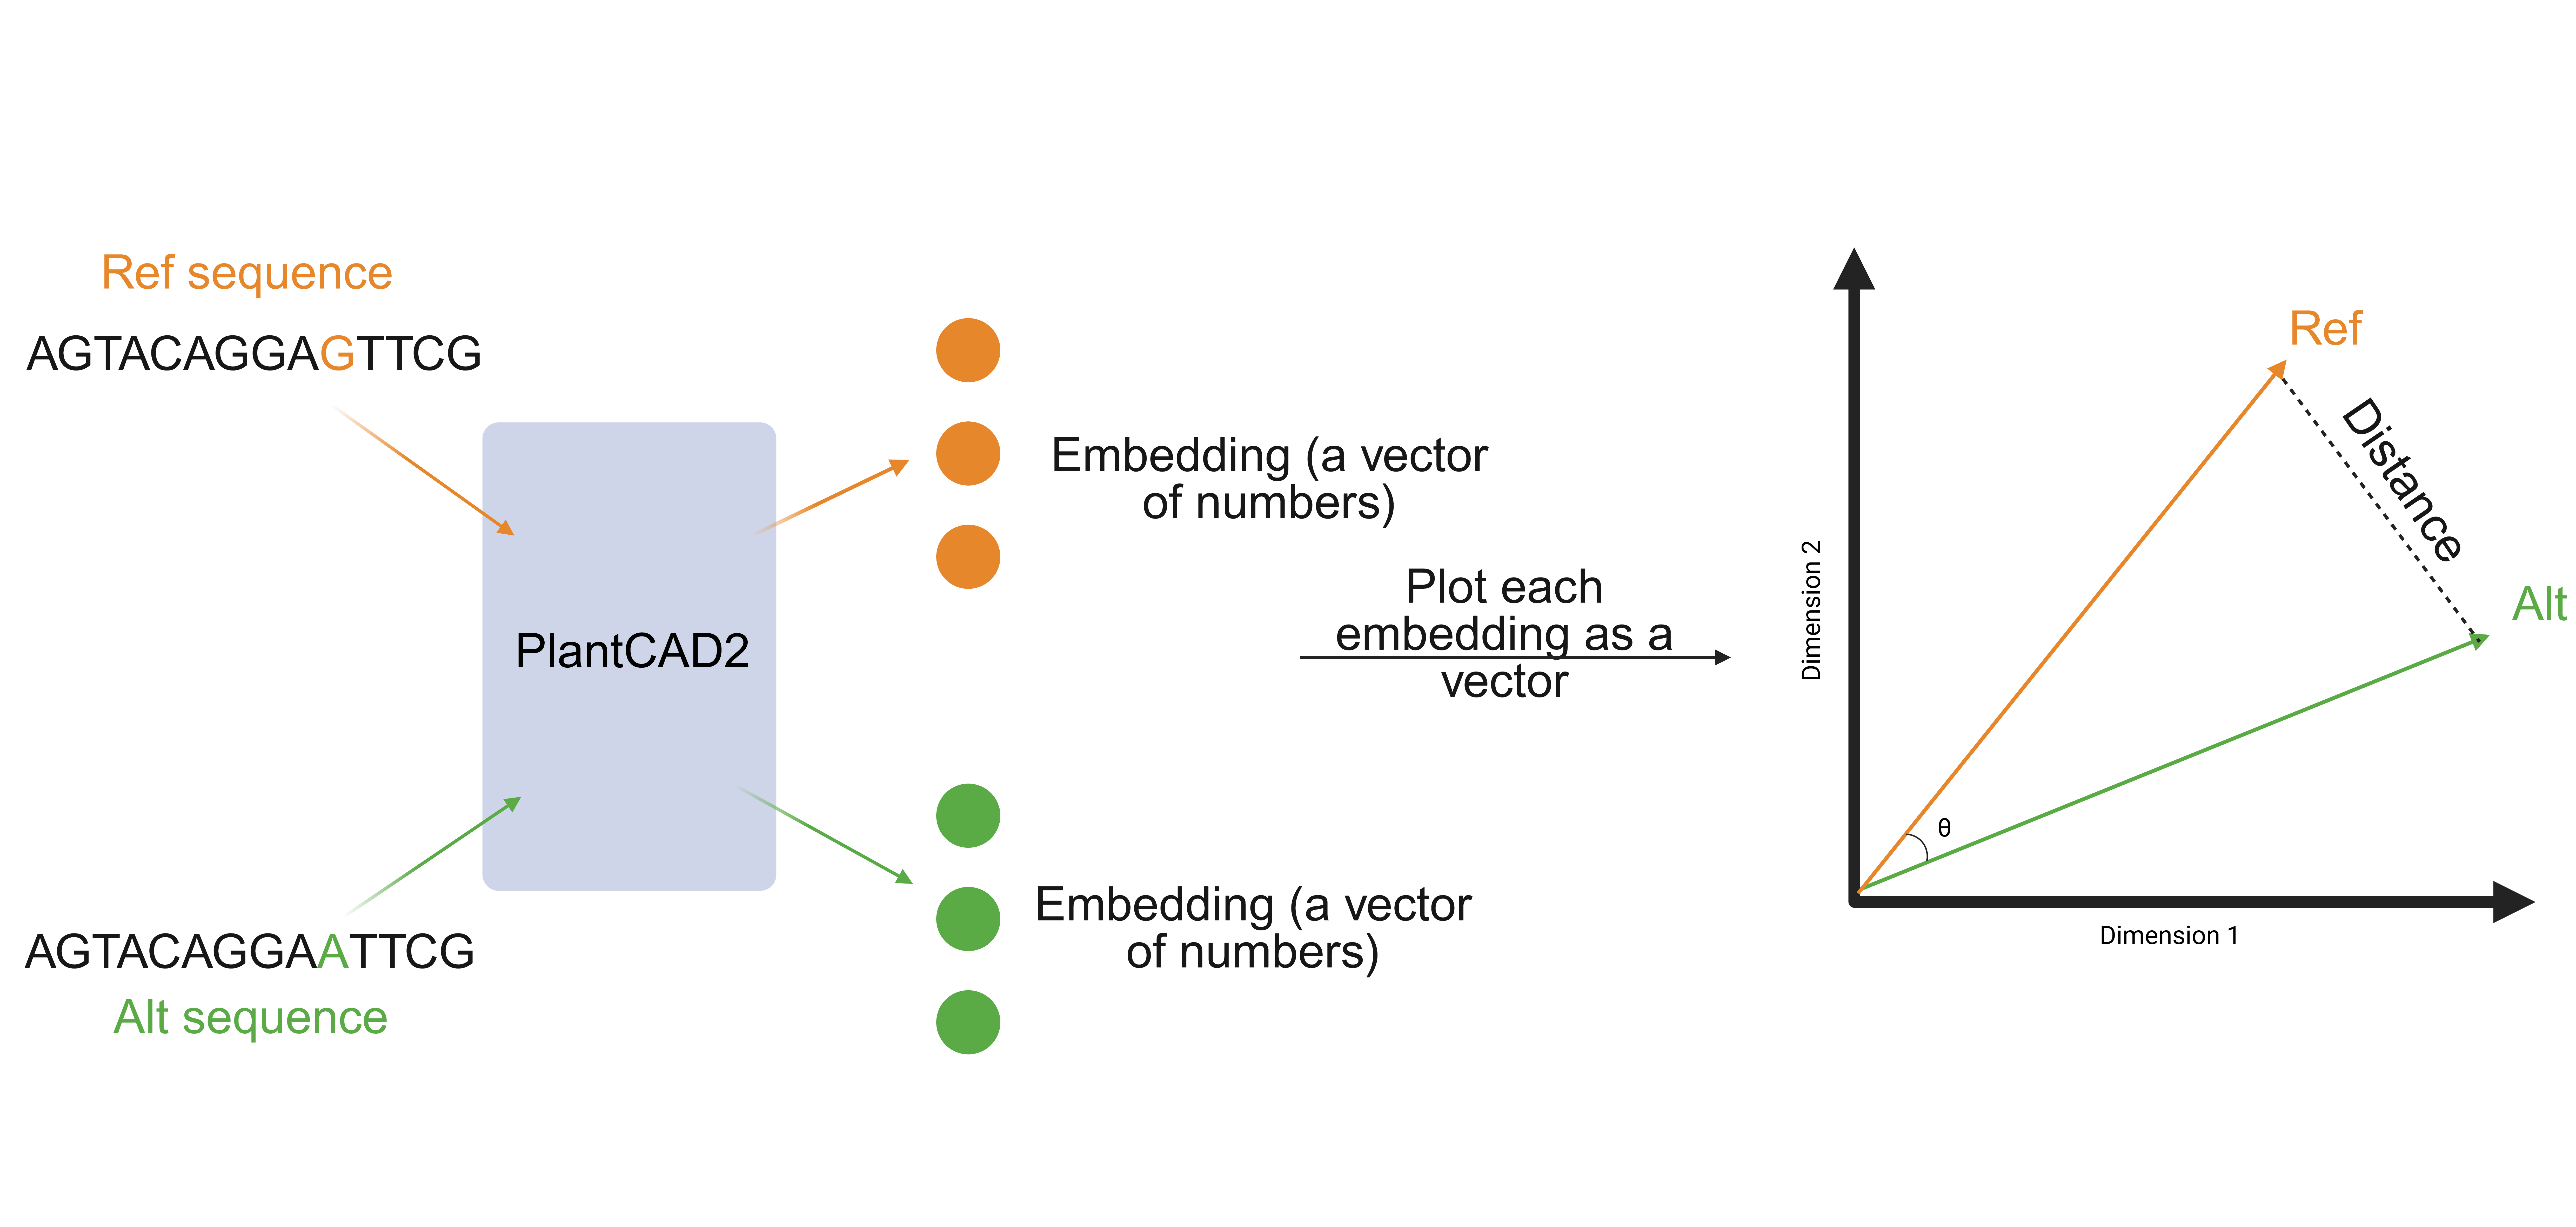

Rather than just predicting the likelihood of alleles at a single position, we can use Plant Caduceus to predict what it thinks of the overall effect of the sequence.

This is captured in embeddings, which represent how the model understands the structure and meaning of the entire sequence (other embeddings can capture individual SNP meanings).

A large difference between a REF and ALT sequence embedding suggests the model thinks there is a large difference in their biological effect.

If the only difference in these sequences is a single SNP, then this represents the impact of the SNP on the entire sequence.

First we will extract the embeddings for our REF and ALT sequences

In [ ]:
# function to convert DNA sequence to numeric embedding vector
def get_embedding(sequence):
    """
    Generates an embedding for a DNA sequence using the loaded PlantCAD2 model.
    """
    # 1. Tokenize the input sequence
    inputs = tokenizer(sequence, return_tensors="pt").to(device)

    # 2. Filter inputs: The PlantCAD2 model only expects 'input_ids'
    # It does not accept 'token_type_ids' or 'attention_mask'
    model_inputs = {'input_ids': inputs['input_ids']}

    # 3. Forward pass through the model
    with torch.no_grad():
        outputs = model(**model_inputs, output_hidden_states=True)

    # 4. Extract the last hidden state and mean pool
    # The last hidden state is at index -1 of hidden_states if not in attribute
    if hasattr(outputs, 'last_hidden_state'):
        embeddings = outputs.last_hidden_state.mean(dim=1)
    else:
        embeddings = outputs.hidden_states[-1].mean(dim=1)

    return embeddings.cpu().squeeze().numpy()

# Example usage for one sequence in our dataframe:
if not df_snps.empty:
    example_seq = df_snps.iloc[2]['sequence']
    example_emb = get_embedding(example_seq)
    print(f"Generated embedding for {df_snps.iloc[2]['snp_id']} ({df_snps.iloc[2]['type']})")
    print(f"Embedding shape: {example_emb.shape}")

In [ ]:
# run the embedding process
# note that this takes about 1 min per 200 sequences on the T4 GPU
from tqdm.auto import tqdm
tqdm.pandas()

print("Re-generating embeddings for all SNP sequences...")
df_snps['embedding'] = df_snps['sequence'].progress_apply(get_embedding)

display(df_snps.head())

Now we will compare and score the difference between the REF and ALT embeddings for each sequence.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

scores = []
for snp_id in df_snps['snp_id'].unique():
    ref_emb = df_snps[(df_snps['snp_id'] == snp_id) & (df_snps['type'] == 'REF')]['embedding'].iloc[0].reshape(1, -1)
    alt_emb = df_snps[(df_snps['snp_id'] == snp_id) & (df_snps['type'] == 'ALT')]['embedding'].iloc[0].reshape(1, -1)

    # Calculate Cosine Similarity (1 = identical, 0 = orthogonal)
    similarity = cosine_similarity(ref_emb, alt_emb)[0][0]
    # Distance = 1 - similarity
    distance = 1 - similarity

    scores.append({'snp_id': snp_id, 'cosine_similarity': similarity, 'variant_score': distance})

df_scores = pd.DataFrame(scores)

# Sort by variant_score descending to see most impactful mutations first
df_scores = df_scores.sort_values(by='variant_score', ascending=False)

print("Variant impact scores (sorted by highest impact first):")
display(df_scores.head(20))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_scores['variant_score'], bins=50, kde=True, color='skyblue')

plt.title('Distribution of Variant Scores (Cosine Distance)', fontsize=15)
plt.xlabel('Variant Score (Impact)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

### Expression Prediction score

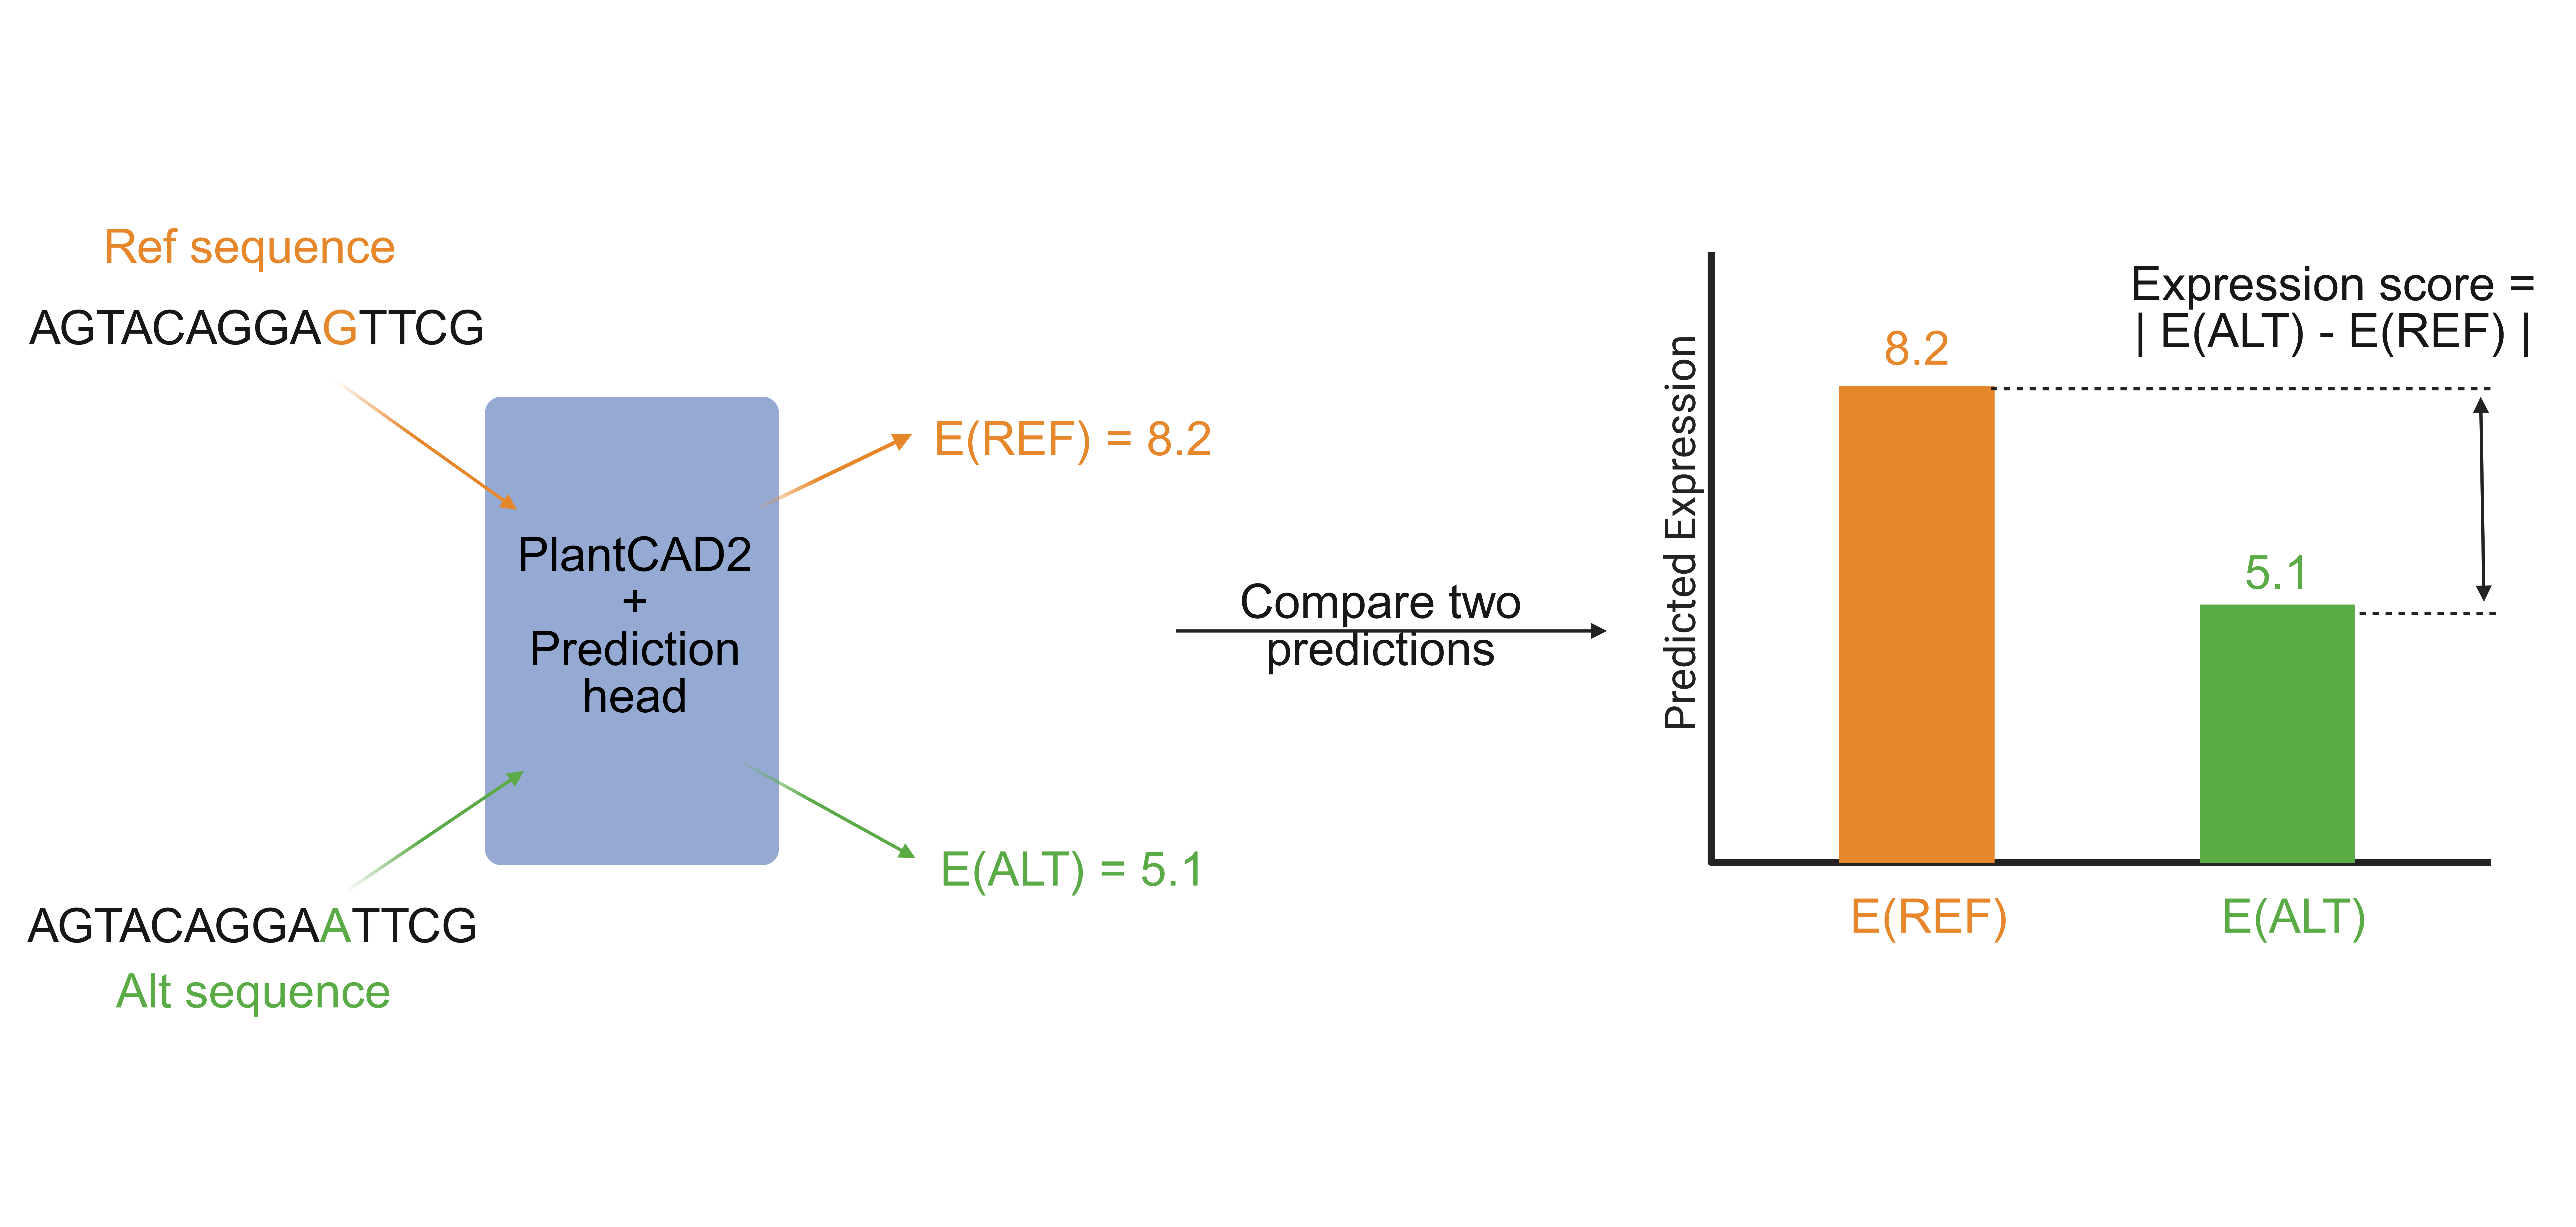

Our final method uses a fine-tuned version of Plant Caduceus to predict the expression of a gene given a sequence. Here we are predicting based on RNA-seq data.

This model was trained using nucleotide sequences of genes and their surrounding 50kb regions. So it is capable of predicting some promoter effects upon gene expression.

While gene expression is controlled by many environmental, genetic and cellular processes, we can obtain a rough idea of the expression difference between our REF and ALT sequence this way (though probably not the absolute values of expression).

In [ ]:
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Uses the fine-tuned expression model (`expr_model` / `expr_tokenizer`) that was
# loaded up front alongside the base model. Unlike the cosine / embedding metrics
# above (which measure how far the *base* model's representation moves), this score
# is a genuine predicted change in absolute leaf expression between the two alleles:
#     expr_score = | E(ALT) - E(REF) |
# This is an INDEPENDENT, phenotype-relevant signal, not another embedding distance.

@torch.no_grad()
def predict_expression(sequence):
    """Predicted absolute leaf expression for a single sequence."""
    inputs = expr_tokenizer(sequence, return_tensors="pt").to(device)
    # Call the underlying Caduceus model directly. The PeftModel sequence-
    # classification wrapper injects attention_mask=None into forward(), but
    # CaduceusForSequenceClassification.forward() doesn't accept attention_mask
    # (PlantCAD2 only takes input_ids -- same as get_embedding above). LoRA weights
    # and the trained 'score' head are still applied on the base model.
    out = expr_model.get_base_model()(input_ids=inputs["input_ids"])
    return out.logits.squeeze().item()

def get_expression_prediction_score(ref_seq, alt_seq):
    """Impact = magnitude of the predicted expression change between REF and ALT."""
    return abs(predict_expression(ref_seq) - predict_expression(alt_seq))

print("Calculating Expression Prediction Scores (predicted delta-expression)...")
# Two forward passes per SNP (REF and ALT); done over ALL SNPs so the Ensemble
# cell can reuse these instead of recomputing.
expr_results = []
unique_ids = df_snps['snp_id'].unique()

for sid in tqdm(unique_ids):
    ref_seq = df_snps[(df_snps['snp_id'] == sid) & (df_snps['type'] == 'REF')]['sequence'].iloc[0]
    alt_seq = df_snps[(df_snps['snp_id'] == sid) & (df_snps['type'] == 'ALT')]['sequence'].iloc[0]
    e_ref = predict_expression(ref_seq)
    e_alt = predict_expression(alt_seq)
    expr_results.append({
        'snp_id': sid,
        'expr_ref': e_ref,
        'expr_alt': e_alt,
        'expr_delta': e_alt - e_ref,       # signed: + up-regulating, - down-regulating
        'expr_score': abs(e_alt - e_ref),  # magnitude used for impact ranking
    })

df_expr_scores = pd.DataFrame(expr_results)

# Visualization: Distribution of scores
print("Visualizing Expression Score distributions...")
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df_expr_scores['expr_score'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Predicted Expression-Change Scores', fontsize=15)
plt.xlabel('Expression Score  |E(ALT) - E(REF)|', fontsize=12)
plt.ylabel('Frequency (SNP Count)', fontsize=12)
plt.show()

display(df_expr_scores.sort_values(by='expr_score', ascending=False).head(10))

# After it finishes, drop this in a scratch cell to confirm the trained head is live (values should show a real spread, not all identical):

print(df_expr_scores[['expr_ref','expr_alt','expr_score']].describe())

In [ ]:
print("embedding col:", 'embedding' in df_snps.columns)
print("df_prob_scores:", 'df_prob_scores' in globals())
print("df_expr_scores:", 'df_expr_scores' in globals())

### Ensemble scores

We've used three different methods of scoring SNPs here which focus on different genetic features.

As all of these features are likely important, we can use an ensemble scoring method to combine them.

In reality, a good ensemble score requires validation, fitting weightings across methods and ablation studies to ensure we're keeping the most important data.

Here we will take a naive average of the SNP rankings across all three methods as an example.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

# 1. Assemble the 3 INDEPENDENT scores for every SNP:
#    - embedding_dist : cosine distance of base-model embeddings  (representation shift)
#    - prob_score     : masked-LM |log p(REF) - log p(ALT)|       (allele plausibility)
#    - expr_score     : |predicted E(ALT) - E(REF)|               (fine-tuned expression head)
unique_ids_all = df_snps['snp_id'].unique()
full_results = []

print("Assembling ensemble scores for all SNPs...")
for sid in tqdm(unique_ids_all):
    ref_rows = df_snps[(df_snps['snp_id'] == sid) & (df_snps['type'] == 'REF')]
    alt_rows = df_snps[(df_snps['snp_id'] == sid) & (df_snps['type'] == 'ALT')]

    ref_emb = ref_rows['embedding'].iloc[0]
    alt_emb = alt_rows['embedding'].iloc[0]

    # Method 1: Embedding distance (cosine) on base-model embeddings
    sim = cosine_similarity(ref_emb.reshape(1, -1), alt_emb.reshape(1, -1))[0][0]
    emb_dist = 1 - sim

    # Method 2: Masked-LM nucleotide probability score (reuse if already computed)
    if sid in df_prob_scores['snp_id'].values:
        prob_score = df_prob_scores.loc[df_prob_scores['snp_id'] == sid, 'prob_score'].iloc[0]
    else:
        snp_info = next(item for item in snp_list if item['id'] == sid)
        prob_score, _, _ = get_nucleotide_probability_score(
            ref_rows['sequence'].iloc[0],
            snp_idx=500,
            ref_base=snp_info['ref'],
            alt_base=snp_info['alt']
        )

    # Method 3: Predicted expression change (reuse from the Expression cell)
    if sid in df_expr_scores['snp_id'].values:
        expr_score = df_expr_scores.loc[df_expr_scores['snp_id'] == sid, 'expr_score'].iloc[0]
    else:
        expr_score = get_expression_prediction_score(
            ref_rows['sequence'].iloc[0],
            alt_rows['sequence'].iloc[0]
        )

    full_results.append({
        'snp_id': sid,
        'embedding_dist': emb_dist,
        'expr_score': expr_score,
        'prob_score': prob_score
    })

df_full_comparison = pd.DataFrame(full_results)

# 2. Rank aggregation (mean-rank / Borda count). Rank 1 = highest impact for every metric.
score_cols = ['embedding_dist', 'expr_score', 'prob_score']
rank_cols  = [f'{c}_rank' for c in score_cols]
for c in score_cols:
    df_full_comparison[f'{c}_rank'] = df_full_comparison[c].rank(ascending=False)

# Average ONLY the three metric ranks. Listing rank_cols explicitly (instead of
# filtering columns that contain "rank") keeps this safe to re-run in Colab --
# otherwise 'avg_rank' from a previous run would get averaged into itself.
df_full_comparison['avg_rank'] = df_full_comparison[rank_cols].mean(axis=1)

# Final clean integer ensemble rank (1 = best consensus SNP). Ties share the lower
# rank; this doesn't change the ordering, it just turns the averaged ranks into a
# proper 1..N ordinal for readability.
df_full_comparison['ensemble_rank'] = df_full_comparison['avg_rank'].rank(method='min').astype(int)
df_full_comparison = df_full_comparison.sort_values('ensemble_rank')

print("\nTop 10 Consensus High-Impact SNPs (over all SNPs):")
display(df_full_comparison.head(10))

# 3. Visualization: correlation between the three methods.
plt.figure(figsize=(8, 6))
corr_all = df_full_comparison[score_cols].corr()
sns.heatmap(corr_all, annot=True, cmap='coolwarm', fmt='.3f', vmin=-1, vmax=1)
plt.title("Correlation Between Scoring Methods (All SNPs)")
plt.show()

# Rank the SNPs

With our average rank for all 100 SNPs, we can take the top 10 and bottom 10 ranked SNPs, which become our "most informative" and "least informative" SNP sets.

Later we will use a scaled-up version of these sets for genomic prediction.

**Reflection questions**

*Why select the top and bottom 10% of SNPs?*

*Is a straight average of these models the best ensemble method?*

*What are the criteria for choosing a good DNA foundation model for prediction tasks in our species?*



In [ ]:
df_top_10_snps = df_full_comparison.sort_values(by='ensemble_rank', ascending=True).head(10)

df_bottom_10_snps = (df_full_comparison.sort_values(by="ensemble_rank", ascending=False)
    .head(10)
)

side_by_side = pd.DataFrame({
    "Top SNP": df_top_10_snps["snp_id"].reset_index(drop=True),
    "Top ensemble_rank": df_top_10_snps["ensemble_rank"].reset_index(drop=True),
    "Bottom SNP": df_bottom_10_snps["snp_id"].reset_index(drop=True),
    "Bottom ensemble_rank": df_bottom_10_snps["ensemble_rank"].reset_index(drop=True),
})

# Now we will print the output. col_space just formats the columns nicely.
print(side_by_side.to_string(
    index=False,
    col_space={
        "Top SNP": 15,
        "Top ensemble_rank": 20,
        "Bottom SNP": 15,
        "Bottom ensemble_rank": 20,
    }
))


### Variant effect prediction

*Have you used tools like Ensembl VEP or SNPEff in your workflows?*

Scoring SNPs with DNA foundation models is a new method of variant effect prediction where the structure and meaning of DNA is learnt directly from nucleotide sequences.

But there are other methods of variant effect prediction that rely on human-defined rules.

Ensembl VEP is one such tool, that uses observed motifs to score SNPs. For example, a SNP in a gene that introduces a stop codon would have a high variant effect score.

We won't explore scoring with Ensembl VEP today, but it's important to know there are other approaches out there.

It's important to consider how a model is trained and what rules it's using the score SNP importance. Each model is likely to recognise different genomic features.

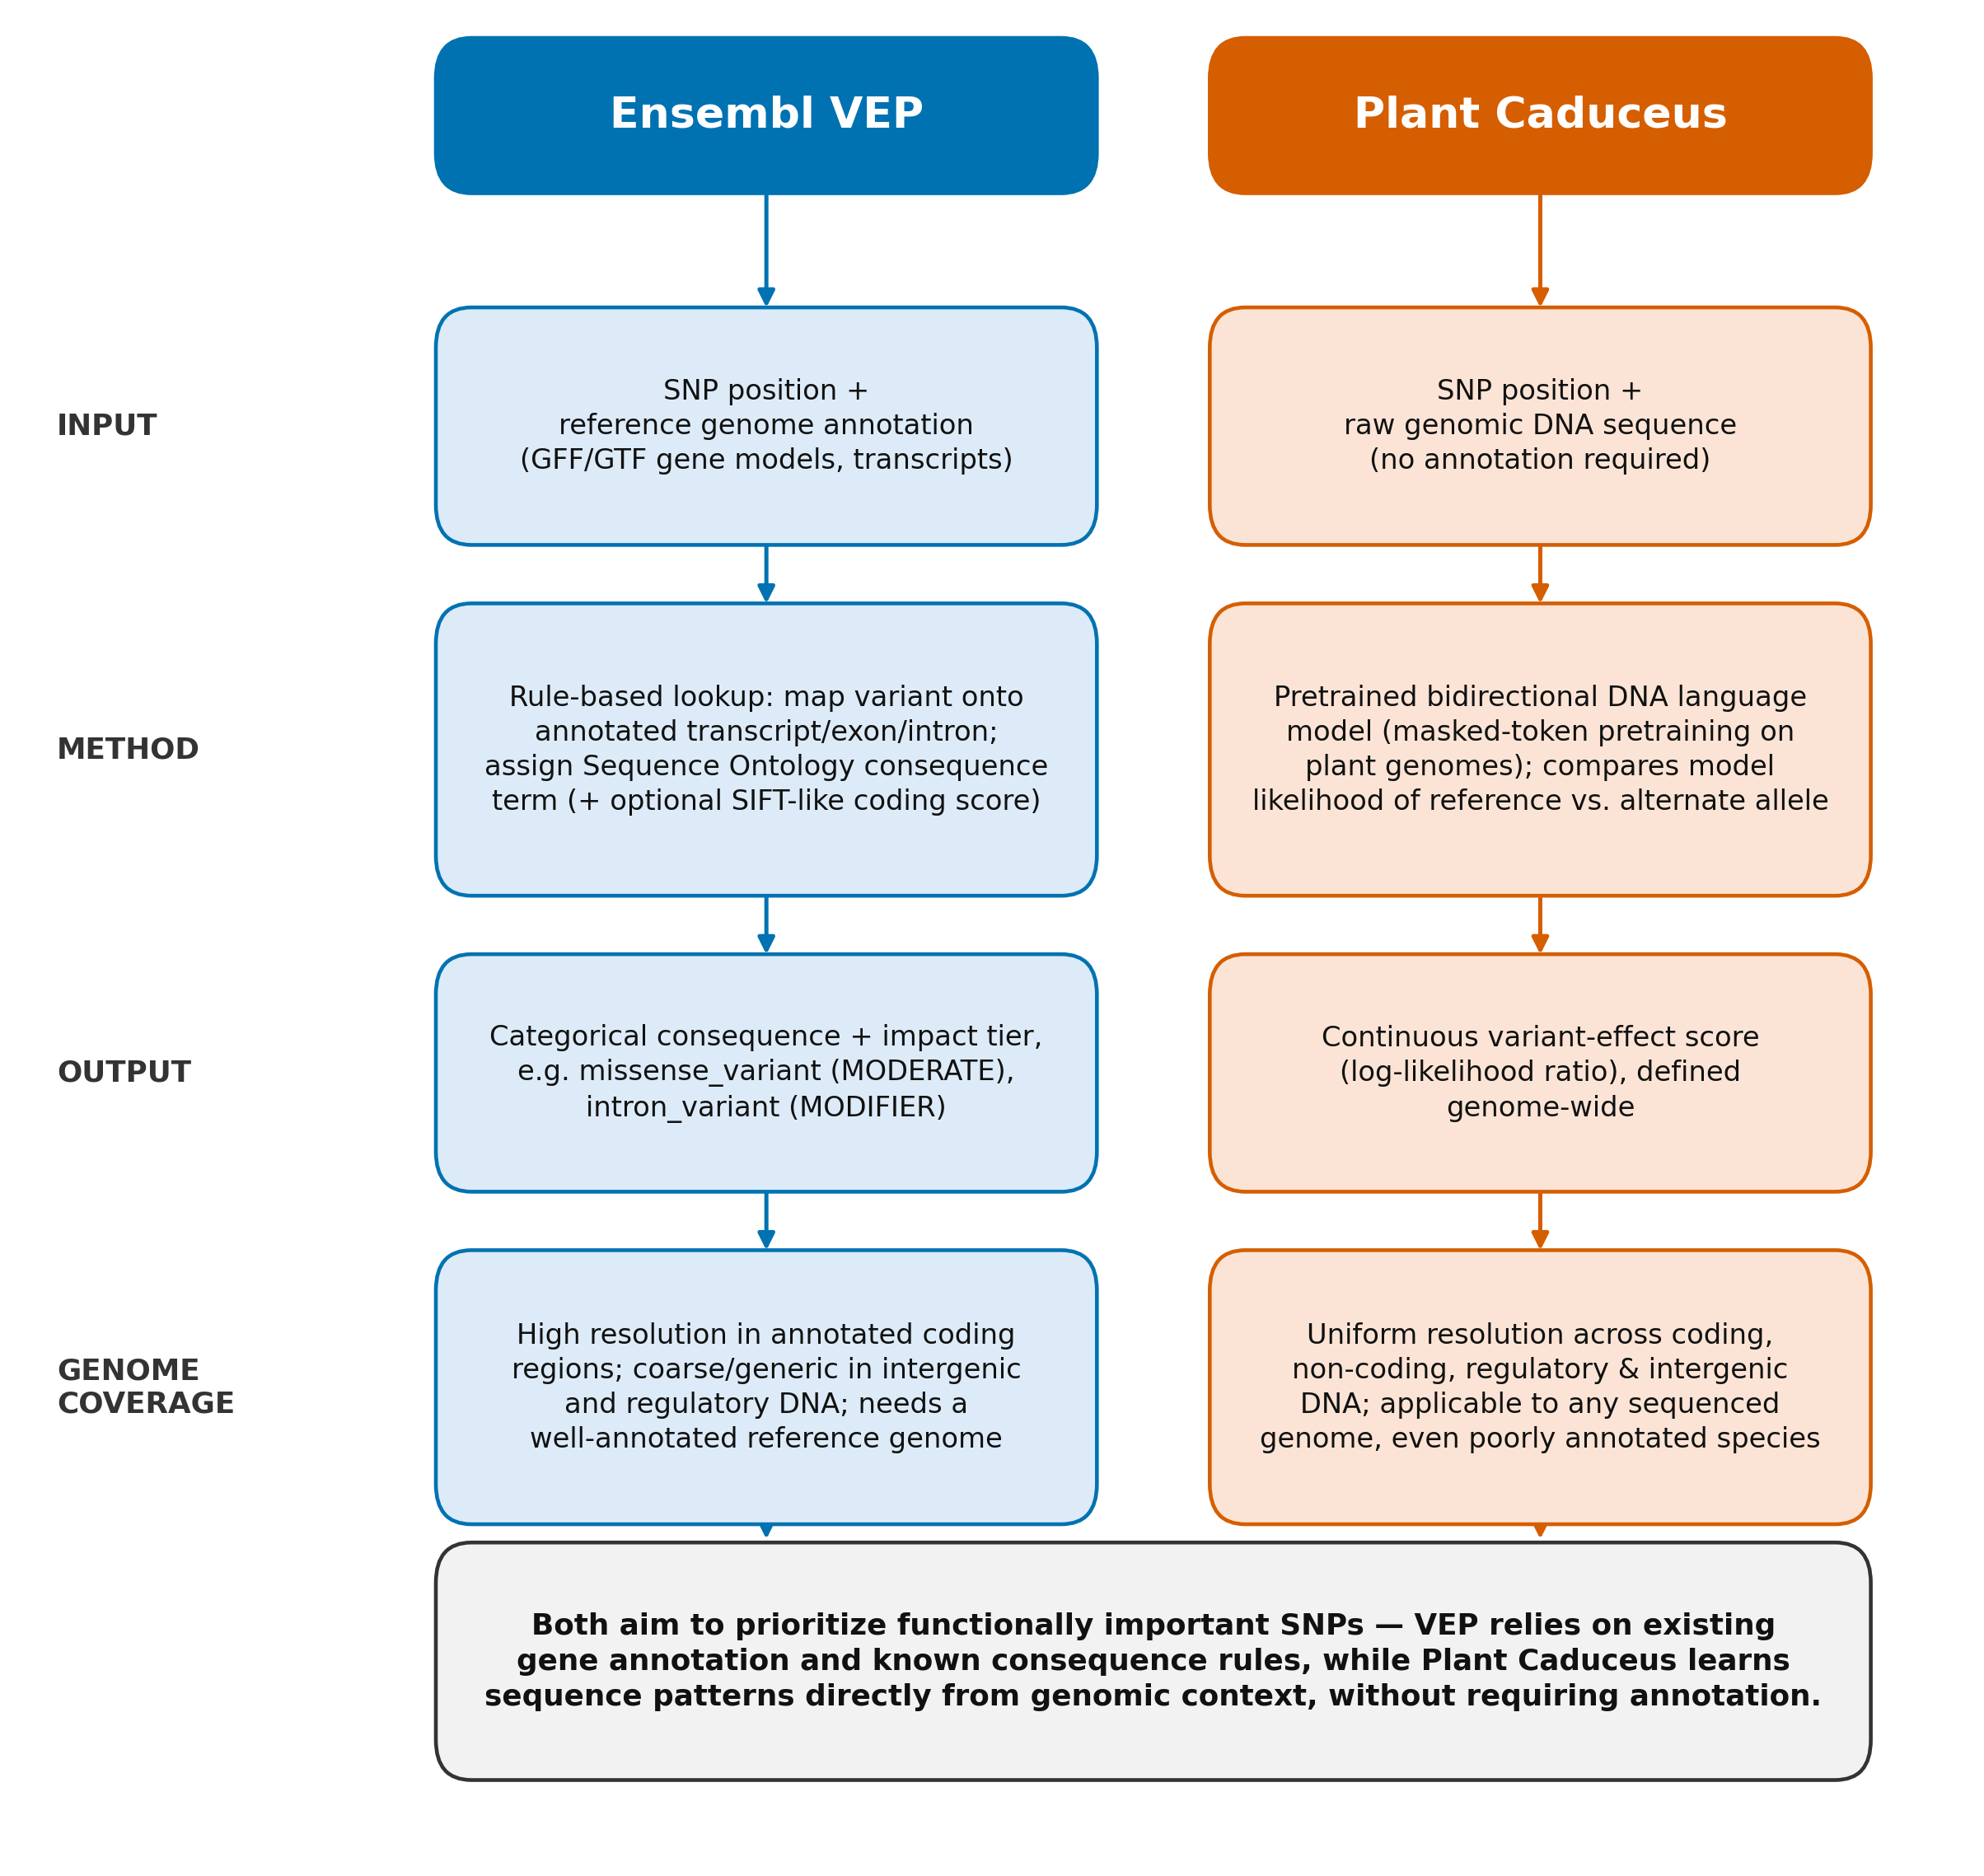

# Genomic Prediction

let's run some genomic prediction for the sorghum 'days to flowering' phenotype.

We're going to analyse four SNP sets:

1. using all 1000 SNPs
2. using the top 100 ranked SNPs ranked by Plant Caduceus
3. using the bottom 100 ranked SNPs
4. using 100 randomly selected SNPs

We can then compare the effect of these SNP sets on prediction accuracy.

**Reflection questions**

*What is a good number of SNPs for genomic prediction?*


*Which genomic prediction model(s) should we use with variant effect prediction?*

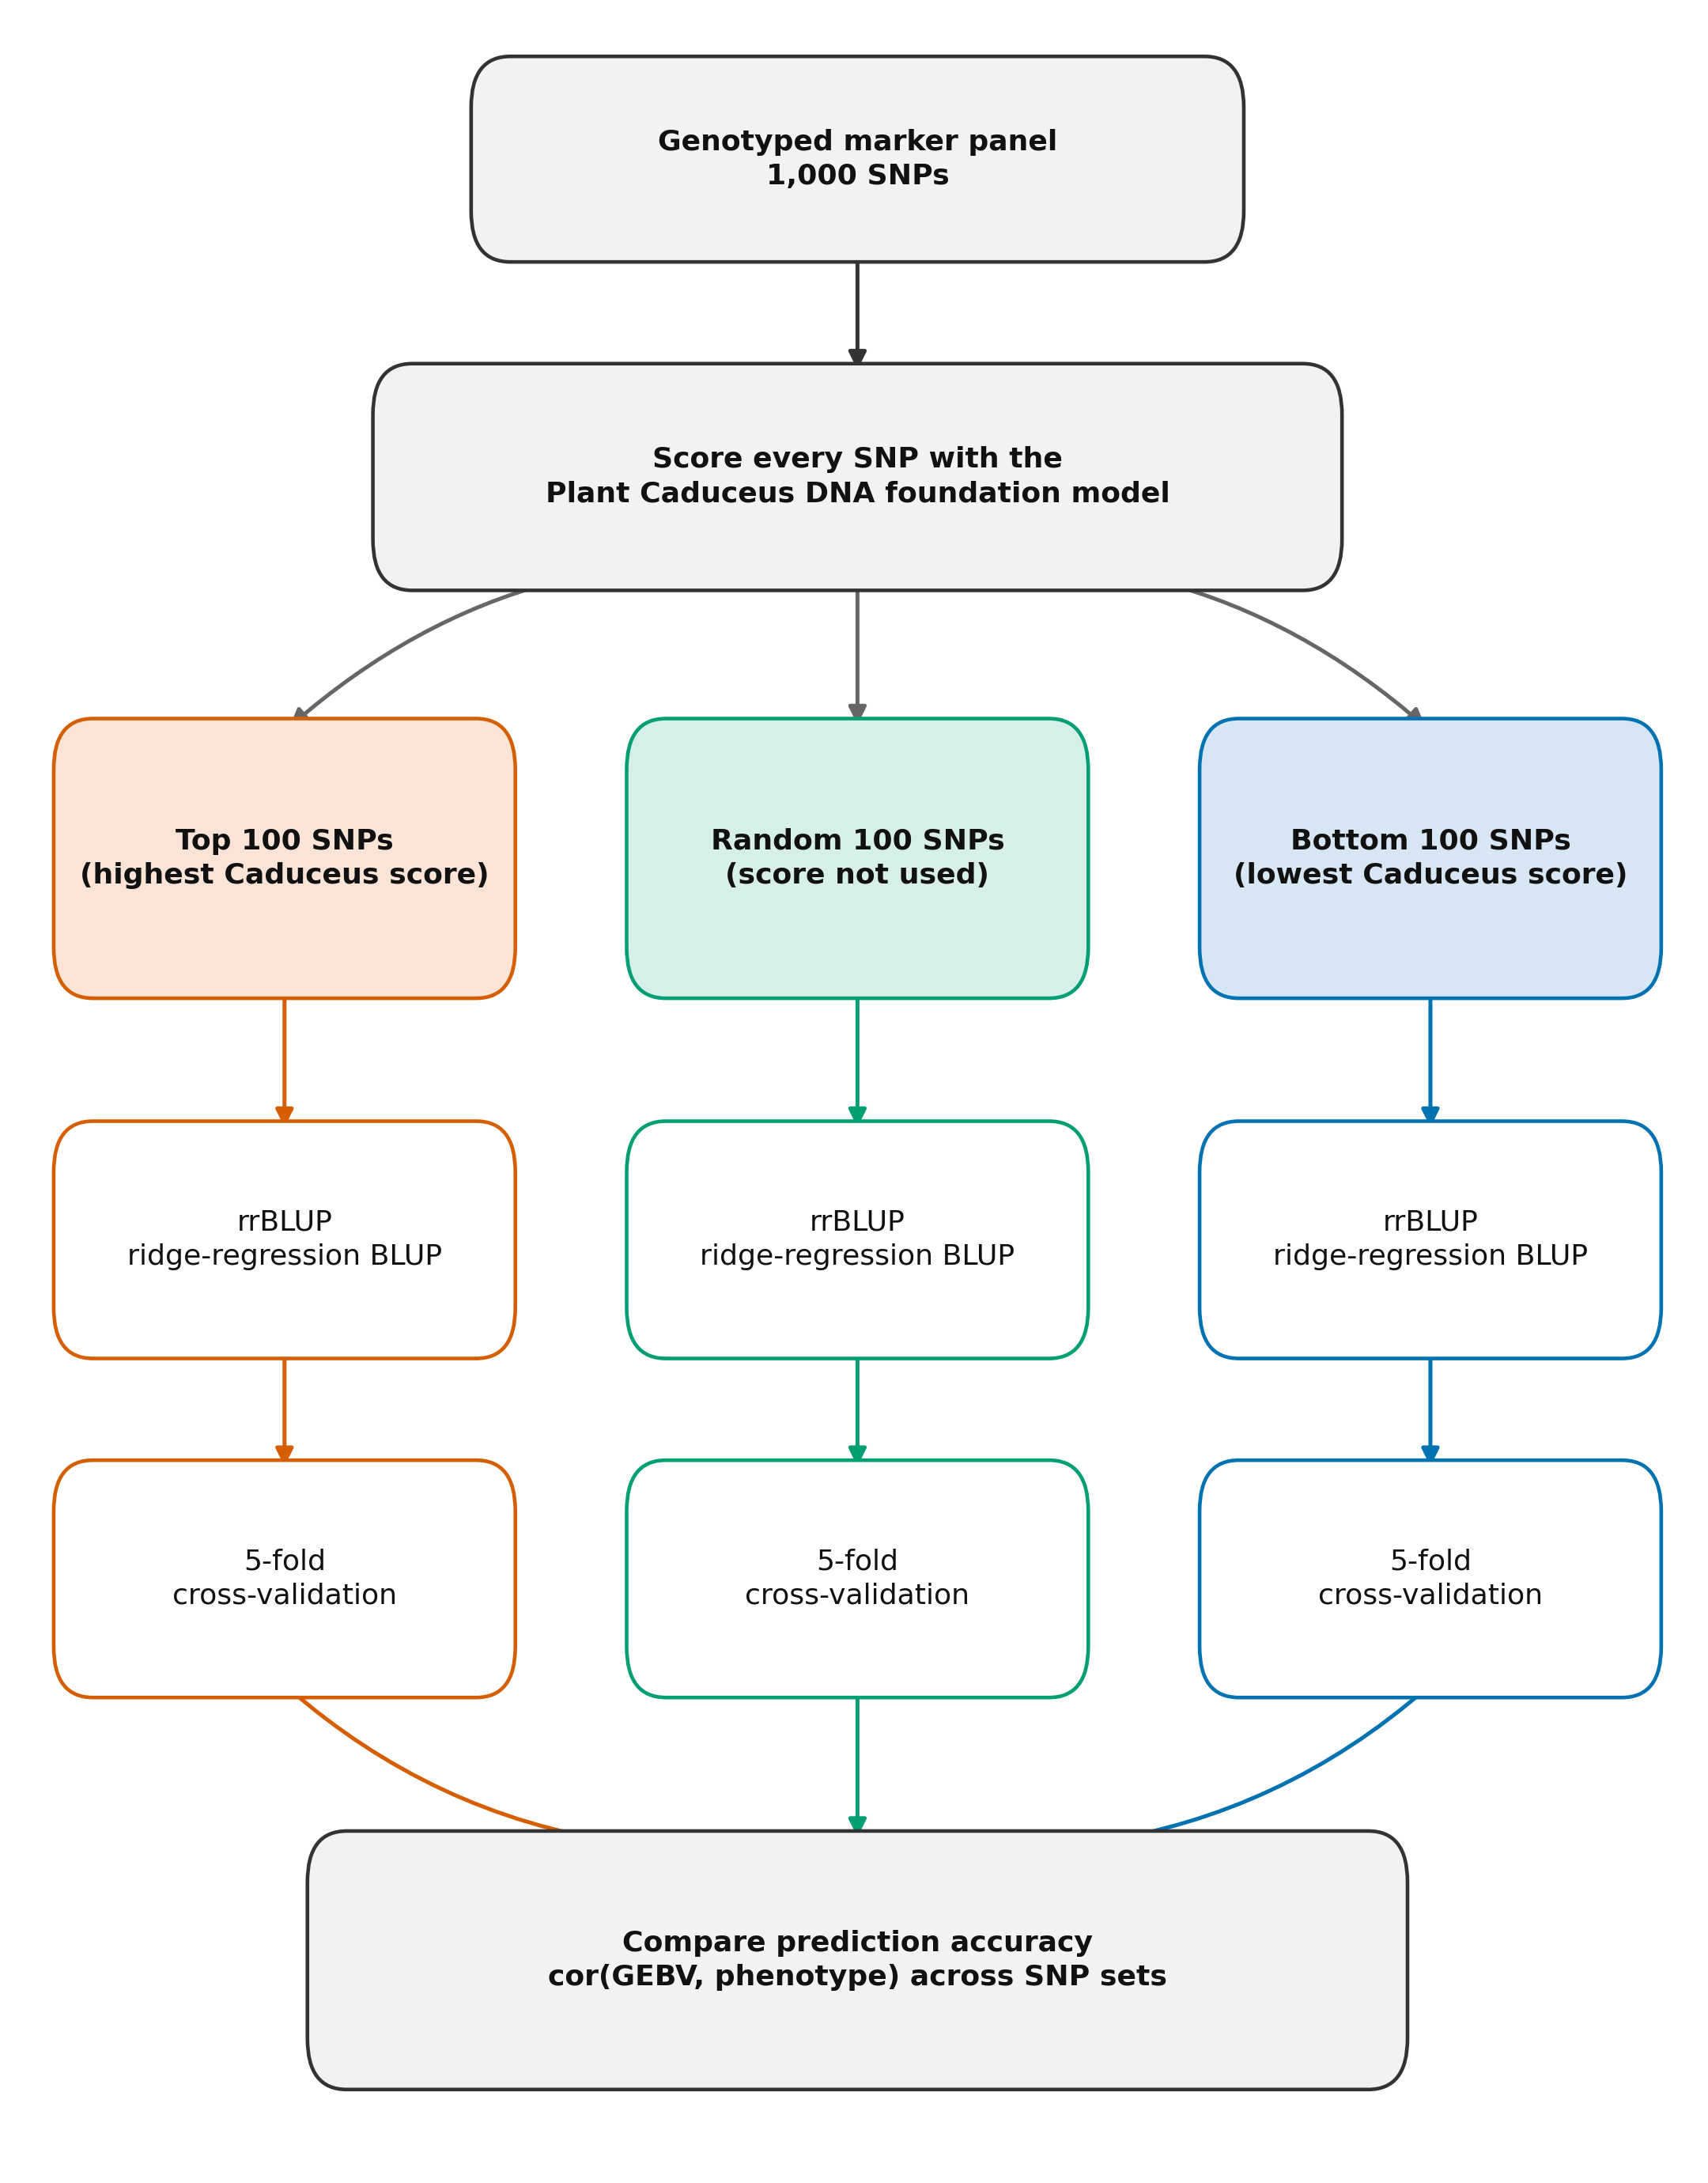

In [ ]:
!pip install rpy2 --no-build-isolation
%load_ext rpy2.ipython

#### Data loading for genomic prediction
* Before performing genomic prediction we need phenotype data and a genotype matrix.

* This will be larger (1000 SNPs) than the data we worked with before, so we will download it directly.

#### Loading SNP scores for genomic prediction

*   We will also need variant effect scores for all 1000 SNPs for us to create SNP sets of 100 top and 100 bottom scoring SNPs.

*  We performed this SNP scoring earlier with a 100 SNP set, ranking the top and bottom 10. We could do the same with a larger set but it's more time consuming.

*   We have pre-generated these scores for use in genomic prediction, so we will download those too.

In [ ]:
# Download our Plant Caduceus effect prediction scores for 1000 SNPs
fmsnps_url = "https://github.com/scicrow/AI_WinterSchool_2026/raw/main/data/260706_df_full_comparison.csv"
fmsnps_path = "/content/260706_df_full_comparison.csv"

!wget -O {fmsnps_path} {fmsnps_url}

print(f"Finished downloading to {fmsnps_path}")

# We will download our phenotype data
pheno_url = "https://github.com/scicrow/AI_WinterSchool_2026/raw/main/data/sap_flowering.pheno"
pheno_path = "/content/sap_flowering.pheno"

!wget -O {pheno_path} {pheno_url}

print(f"Finished downloading to {pheno_path}")


# Download our SNP matrix
snpmtrx_url = "https://github.com/scicrow/AI_WinterSchool_2026/raw/main/data/snp_matrix_1000.csv.gz"
snpmtrx_path = "/content/snp_matrix_1000.csv.gz"

!wget -O {snpmtrx_path} {snpmtrx_url}

print(f"Finished downloading to {snpmtrx_path}")



### All SNPs for Genomic Prediction

First we will extract our phenotype values

Then we will ensure our phenotype and genotype matrices match size and order.

This is a critical step for preventing bugs!

In [ ]:
import numpy as np
import pandas as pd

# Load the phenotype list
pheno = pd.read_csv(pheno_path, sep="\t")

# Remove individuals with missing phenotype (-9.0)
pheno = pheno[pheno["FT_U"] != -9.0]

# Load SNP matrix (gzipped CSV)
geno = pd.read_csv(snpmtrx_path, compression="gzip")

# Use first column as genotype IDs
geno = geno.set_index(geno.columns[0])

# Ensure individuals match phenotype to genotype.
common = pheno["IID"][pheno["IID"].isin(geno.index)] # IID is individual ID (genotype)
print(f"{len(common)} individuals retained")

# subset and reorder so every geno individual matches the y entry.
geno = geno.loc[common]

pheno = (
    pheno
    .set_index("IID")
    .loc[common, ["FT_U"]] # Flowering time (days)
)

# Verify alignment
assert np.array_equal(geno.index.to_numpy(), pheno.index.to_numpy())

# Let's look at the SNP matrix
print(geno.head())

In [ ]:
# This is a sanity check state
# The shape of the geno matrix should be 358, 1000
# The shape of the pheno array should be 358, 1
# The pheno array should have an IID (genotype) inex and FT_U (flowering time) column
print(geno.shape)
print(pheno.shape)
print(pheno.head())

Now, with phenotype and genotype data we can run a GBLUP with 1000 SNPs across 523 accessions to assess the prediction accuracy for panicle length using all 1000 SNPs

In [ ]:
# Convert your geno and pheno pandas matrices into R objects
import pandas as pd
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri

pandas2ri.activate()
%R -i geno -i pheno

%R colnames(pheno)
%R head(pheno)

Next we will install rrBLUP for genomic prediction.
From now on we'll mostly be working in R, as it has many readily available genomic prediction and analysis packages.

In [ ]:
%%R

# Load rrBLUP in R for genomic prediction
install.packages("rrBLUP", repos="https://cloud.r-project.org")
library(rrBLUP)
packageVersion("rrBLUP")

#### Perform 5-fold cross-validation
Now we will create a function we will reuse several times for cross validation of our different predictions.

This involves hiding 20% of our phenotype values each run, then predicting those missing values.

Running this five times means we predict all the values in our training set.

1. Split phenotypes into 5 groups.
2. Mask phenotypes from one group.
3. Fit RR-BLUP to the remaining phenotypes
4. Predict the masked phenotypes.
5. Repeat until all 5 groups have been predicted.

Typically we would also want a test set which that model hasn't been fit on at all, the gauge its ability to predict on new data.

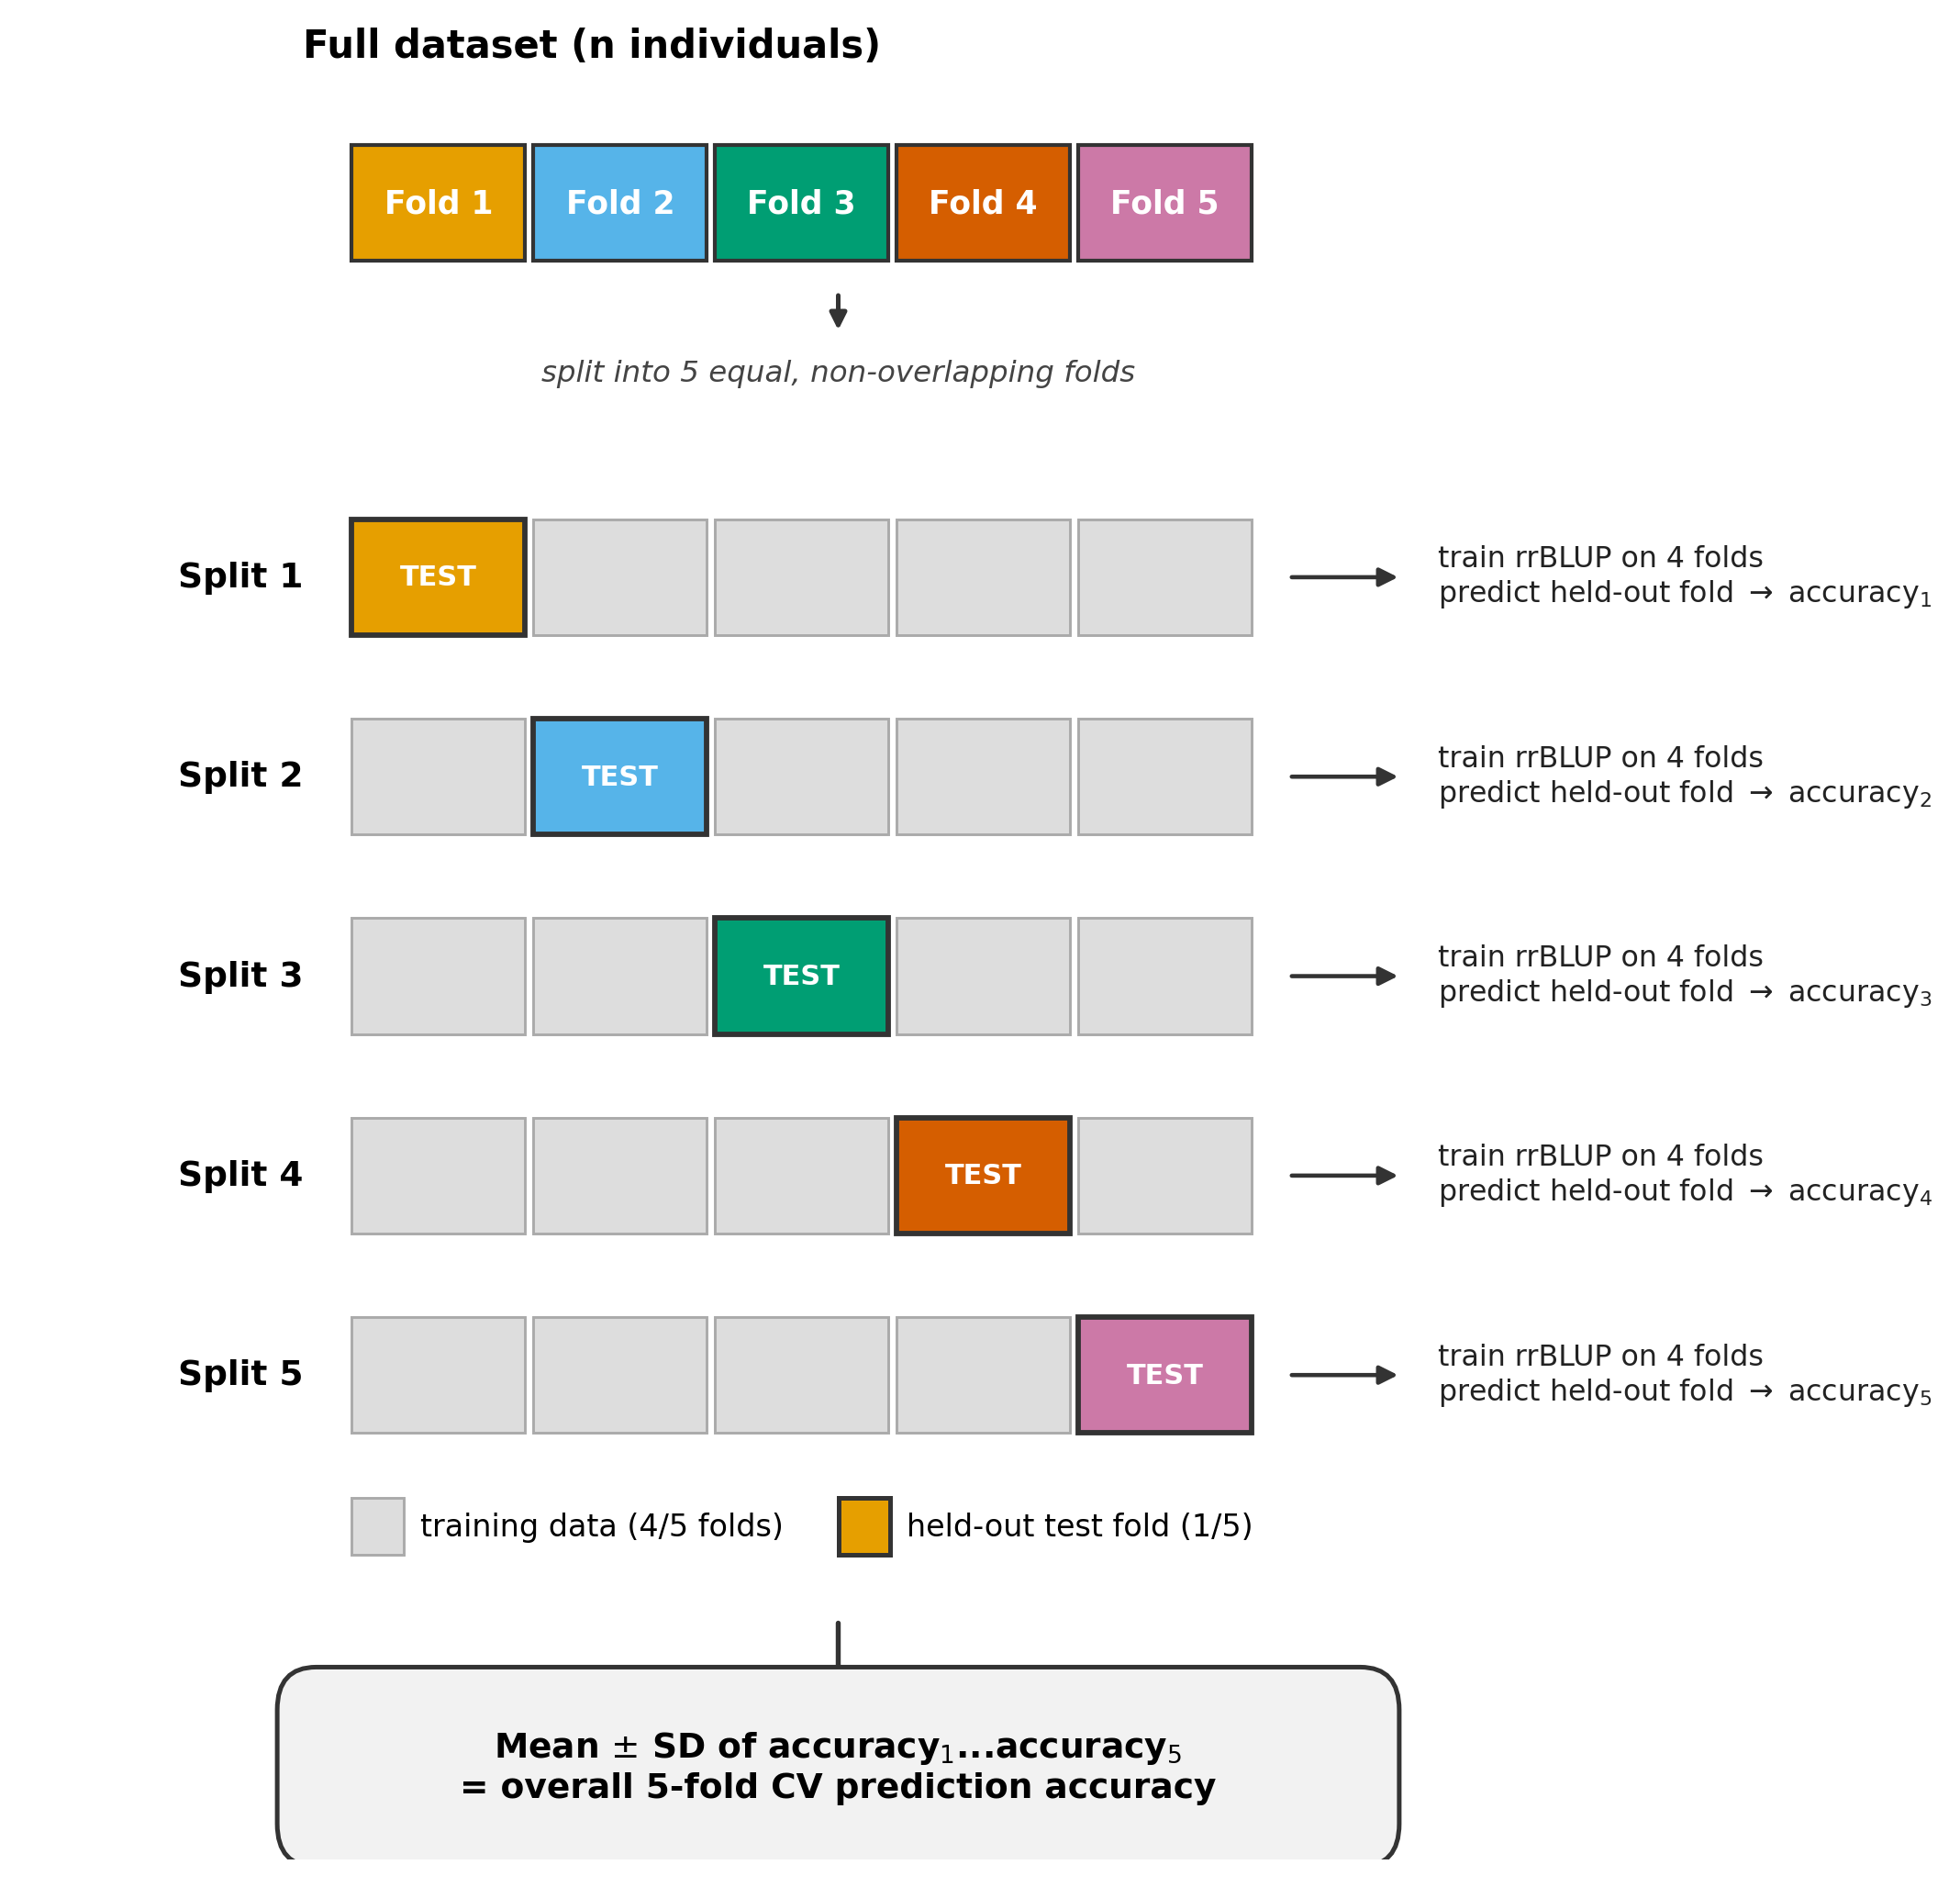

In [ ]:
%%R

library(rrBLUP)

rrblup_cv <- function(X, y, folds = NULL){

    X <- as.matrix(X)

    n <- nrow(X)

    if(is.null(folds)){
        set.seed(123)
        folds <- sample(rep(1:5, length.out = n))
    }

    pred <- rep(NA, n)
    fold_r <- rep(NA, 5)

    for(fold in 1:5){

        train <- folds != fold
        test  <- folds == fold

        fit <- mixed.solve(
            y = y[train],
            Z = X[train, ]
        )

        pred[test] <- as.vector(
            X[test, ] %*% fit$u
        ) + as.numeric(fit$beta)

        fold_r[fold] <- cor(y[test], pred[test], use = "complete.obs")
    }

    rmse <- sqrt(mean((y - pred)^2, na.rm = TRUE))
    r_all <- cor(y, pred, use = "complete.obs")

    list(
        pred = pred,
        r = r_all,
        rmse = rmse,
        fold_r = fold_r,
        sd_fold_r = sd(fold_r, na.rm = TRUE)
    )
}

print("Successfully loaded the rrBLUP genomic prediction function")

Now we will run our cross-validation and extract accuracy.

In [ ]:
%%R

print("Running 5-fold cross-validation for all 1000 SNPs...")
X_all <- as.matrix(geno)

y <- pheno$FT_U

res_all <- rrblup_cv(X_all, y)

print("Predictions complete.")
cat("correlation (r) =", res_all$r, "\n")
cat("RMSE =", res_all$rmse, "\n")

Now we will assess and plot our results.
1. Extract the accuracy of the model across its runs
2. Calculate root mean square error (RMSE)
3. Calculate standard deviation (SD) and obtain relative RMSE. This shows how large our prediction errors are compared to natural variation in the trait.
4. Plot our prediction accuracy (r)



In [ ]:
%%R

accuracy <- res_all$r
rmse <- res_all$rmse
rel_rmse <- rmse / sd(y, na.rm = TRUE)

plot(
    y,
    res_all$pred,
    pch = 19,
    xlab = "Observed phenotype",
    ylab = "Predicted phenotype",
    main = paste0(
        "5-fold RR-BLUP (r = ",
        round(accuracy, 3),
        ", RMSE/SD = ",
        round(rel_rmse, 3),
        ")"
    )
)

abline(lm(res_all$pred ~ y), lwd = 2, lty = 2)

### Use Plant Caduceus in Genomic Prediction

Now we will use the top 100 and bottom 100 SNPs ranked by the Plant Caduceus model as inputs into two rrBLUP genomic prediction pipelines.

First we need to load our scored SNP set and filter these SNPs.

In [ ]:
import pandas as pd

# Load Plant Caduceus SNP scores
fmsnps = pd.read_csv(fmsnps_path)

# Select top 100 SNPs with lowest avg_rank
top100_snps = (
    fmsnps
    .sort_values(by="avg_rank", ascending=True)
    .head(100)
)

bottom100_snps = (
    fmsnps
    .sort_values(by="avg_rank", ascending=True)
    .tail(100)
)

# Convert these to lists for filtering our SNP matrix
top100_snp_ids = top100_snps["snp_id"].tolist()
bottom100_snp_ids = bottom100_snps["snp_id"].tolist()

side_by_side = pd.DataFrame({
    "Top SNP": top100_snps["snp_id"].reset_index(drop=True),
    "Top ensemble_rank": top100_snps["ensemble_rank"].reset_index(drop=True),
    "Bottom SNP": bottom100_snps["snp_id"].reset_index(drop=True),
    "Bottom ensemble_rank": bottom100_snps["ensemble_rank"].reset_index(drop=True),
})


# Now we will print the output. col_space just formats the columns nicely.
print("Extracting the top and bottom 100 SNPs. Subset of 10 shown below. \n")
print(side_by_side.head(10).to_string(
    index=False,
    col_space={
        "Top SNP": 15,
        "Top ensemble_rank": 20,
        "Bottom SNP": 15,
        "Bottom ensemble_rank": 20,
    }
))


### Top 100 SNPs for GP

In [ ]:
import numpy as np
import pandas as pd

# Filter genotype matrix for top 100 SNPs (columns only)
geno_top100 = geno.loc[:, geno.columns.isin(top100_snp_ids)]

# Ensure genotype row order still matches phenotype order
assert np.array_equal(geno_top100.index, pheno.index)

# Should have a shape of 237 genotypes and 100 SNPs
print(geno_top100.shape)

In [ ]:
# Convert your geno_filtered and pheno pandas matrices into R objects
import pandas as pd
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri

pandas2ri.activate()
%R -i geno_top100 -i pheno
print("imported genotypes and phenotypes into R")

In [ ]:
%%R

print("Running 5-fold cross-validation for the top 100 SNPs...")

X_top100 <- as.matrix(geno_top100)
y <- pheno$FT_U

res_top100 <- rrblup_cv(X_top100, y)

print("Predictions complete.")

cat("correlation (r) =", res_top100$r, "\n")
cat("RMSE =", res_top100$rmse, "\n")

# Plot top 100 SNP model
accuracy_top100 <- res_top100$r
rmse_top100 <- res_top100$rmse
rel_rmse_top100 <- rmse_top100 / sd(y, na.rm = TRUE)

plot(
    y,
    res_top100$pred,
    pch = 19,
    xlab = "Observed phenotype",
    ylab = "Predicted phenotype",
    main = paste0(
        "5-fold RR-BLUP Top 100 SNPs (r = ",
        round(accuracy_top100, 3),
        ", RMSE/SD = ",
        round(rel_rmse_top100, 3),
        ")"
    )
)

abline(lm(res_top100$pred ~ y), lwd = 2, lty = 2)

Finally we will compare the accuracy of observed and predicted values in our SNP selected set.

As this is a test set with very few SNPs, the estimation of the genomic relationship matrix (A.mat) struggles when the number of SNPs (m) is very low

### Bottom 100 SNPs for GP

In [ ]:
import numpy as np
import pandas as pd

# Filter genotype matrix for top 100 SNPs (columns only)
geno_bottom100 = geno.loc[:, geno.columns.isin(bottom100_snp_ids)]

# Ensure genotype row order still matches phenotype order
assert np.array_equal(geno_bottom100.index, pheno.index)

# Should have a shape of 237 genotypes and 100 SNPs
print(geno_bottom100.shape)

In [ ]:
# Convert your geno_filtered and pheno pandas matrices into R objects
import pandas as pd
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri

pandas2ri.activate()
%R -i geno_bottom100 -i pheno
print("imported genotypes and phenotypes into R")

In [ ]:
%%R

print("Running 5-fold cross-validation for the bottom 100 SNPs...")

X_bottom100 <- as.matrix(geno_bottom100)
y <- pheno$FT_U

res_bottom100 <- rrblup_cv(X_bottom100, y)

print("Predictions complete.")

cat("correlation (r) =", res_bottom100$r, "\n")
cat("RMSE =", res_bottom100$rmse, "\n")

# Plot bottom 100 SNP model
accuracy_bottom100 <- res_bottom100$r
rmse_bottom100 <- res_bottom100$rmse
rel_rmse_bottom100 <- rmse_bottom100 / sd(y, na.rm = TRUE)

plot(
    y,
    res_bottom100$pred,
    pch = 19,
    xlab = "Observed phenotype",
    ylab = "Predicted phenotype",
    main = paste0(
        "5-fold RR-BLUP Bottom 100 SNPs (r = ",
        round(accuracy_bottom100, 3),
        ", RMSE/SD = ",
        round(rel_rmse_bottom100, 3),
        ")"
    )
)

abline(lm(res_bottom100$pred ~ y), lwd = 2, lty = 2)

### Random 100 SNPs for GP

Given we are using a small number of SNPs from one chromosome, we can test the SNP selection of PlantCaduceus more fairly by comparing its top set to a randomly selected 100 SNPs.

In [ ]:
%%R

set.seed(123)

n_iterations <- 10
n_snps <- 100

random_cor_results <- numeric(n_iterations)
random_rmse_results <- numeric(n_iterations)

print("Running 10 random 100 SNP RR-BLUP cross-validations...")

for (i in 1:n_iterations) {

  # Randomly select 100 SNPs
  random_snps <- sample(
    colnames(geno),
    size = n_snps,
    replace = FALSE
  )

  # Filter genotype matrix
  geno_random <- geno[, random_snps]

  # Run 5-fold RR-BLUP cross-validation
  res_random <- rrblup_cv(
    as.matrix(geno_random),
    pheno$FT_U
  )

  # Store results
  random_cor_results[i] <- res_random$r
  random_rmse_results[i] <- res_random$rmse

  print(
    paste(
      "Iteration", i,
      "correlation =", round(res_random$r, 3)
    )
  )
}

# Summary
mean_random_cor <- mean(random_cor_results, na.rm = TRUE)
sd_random_cor <- sd(random_cor_results, na.rm = TRUE)

mean_random_rmse <- mean(random_rmse_results, na.rm = TRUE)

cat(
  "Mean correlation =", round(mean_random_cor, 3), "\n",
  "SD correlation =", round(sd_random_cor, 3), "\n",
  "Mean RMSE =", round(mean_random_rmse, 3), "\n"
)

# Plot distribution
hist(
  random_cor_results,
  main = "Prediction correlations from random 100 SNP panels",
  xlab = "Correlation"
)

abline(
  v = mean_random_cor,
  lwd = 2,
  lty = 2
)

## Summarise the results
Now we will compare the correlation between predicted and observed phenotypes (r) and the relative RMSE across models to see our performance.

In [ ]:
%%R

phenotype_sd <- sd(pheno$FT_U, na.rm = TRUE)

comparison <- data.frame(
  Model = c(
    "Top 100 SNPs",
    "Bottom 100 SNPs",
    "Random 100 SNPs"
  ),
  Mean_Correlation = c(
    res_top100$r,
    res_bottom100$r,
    mean_random_cor
  ),
  RMSE_SD = c(
    res_top100$rmse / phenotype_sd,
    res_bottom100$rmse / phenotype_sd,
    mean_random_rmse / phenotype_sd
  )
)

print(comparison)

In [ ]:
%%R
library(ggplot2)

comparison <- data.frame(
  Model = factor(
    c("All SNPs", "Top 100 SNPs", "Bottom 100 SNPs", "Random 100 SNPs"),
    levels = c("All SNPs", "Top 100 SNPs", "Bottom 100 SNPs", "Random 100 SNPs")
  ),
  Mean_Correlation = c(
    res_all$r,
    res_top100$r,
    res_bottom100$r,
    mean_random_cor
  )
)

ggplot(comparison, aes(x = Model, y = Mean_Correlation)) +
  geom_col(fill = "steelblue", width = 0.7) +
  geom_text(
    aes(label = round(Mean_Correlation, 3)),
    vjust = -0.5,
    size = 4
  ) +
  labs(
    title = "Prediction Correlation by SNP Set",
    x = "",
    y = "Correlation (r)"
  ) +
  ylim(0, max(comparison$Mean_Correlation) * 1.15) +
  theme_minimal(base_size = 14)

Typically we would report the correlation with the standard deviation.

But given we have not repeated our 5-fold cross-validation, we only have the standard deviation across our k-fold predictions, not a more robust standard deviation across repeats.

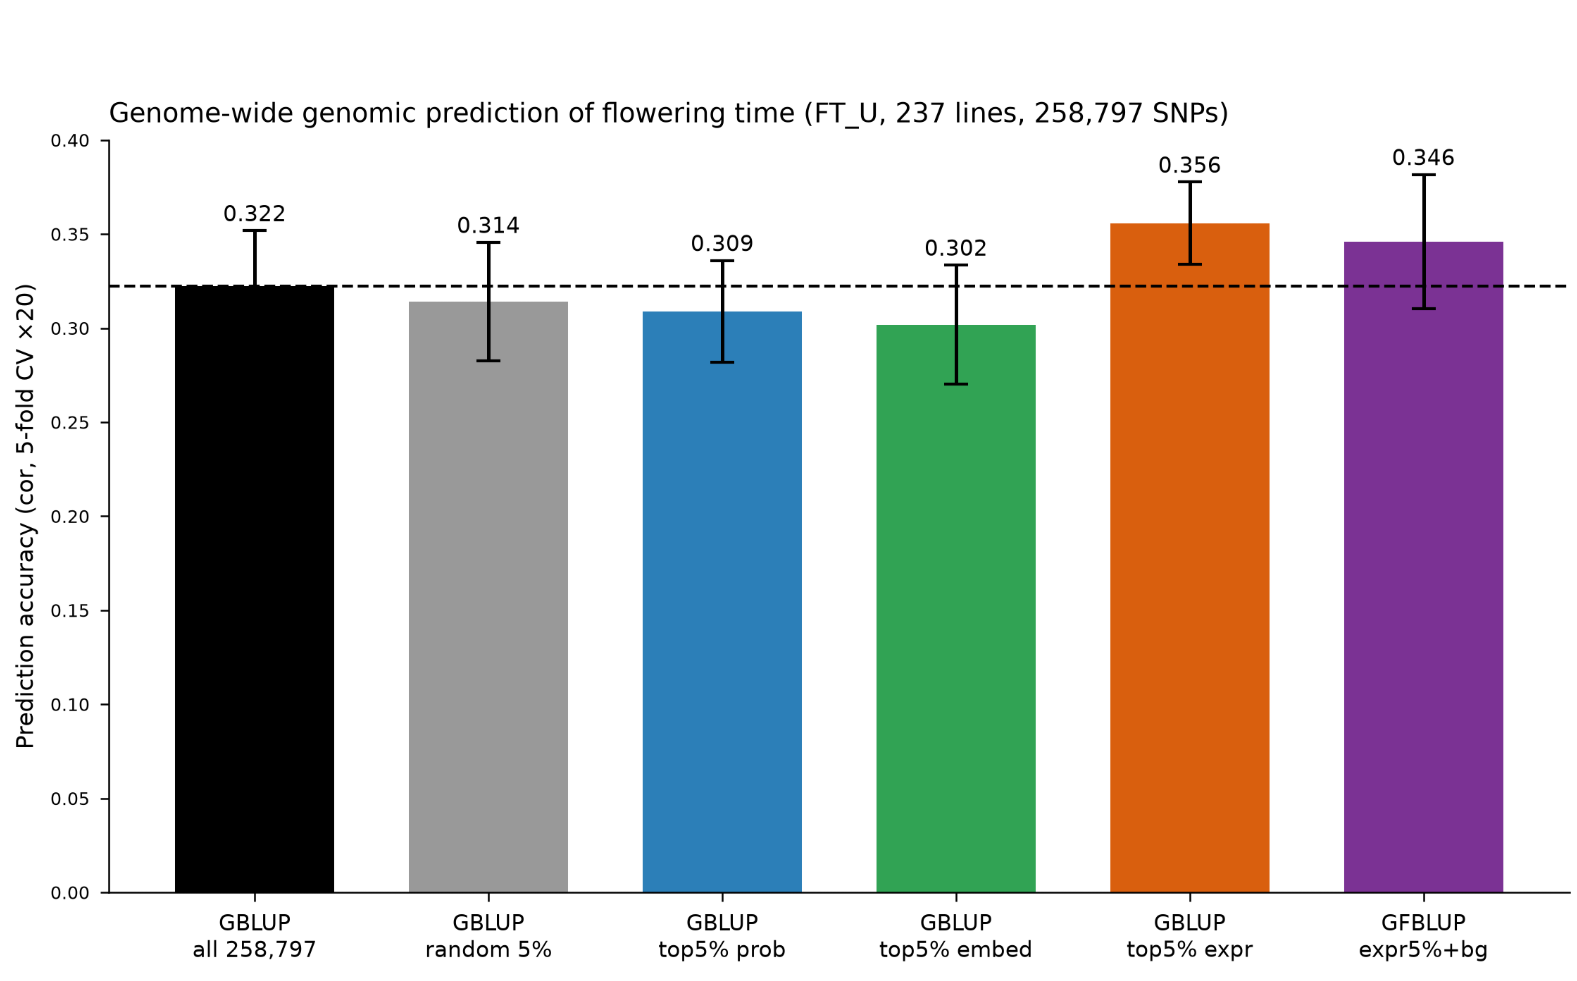

# Conclusion

Our observations here suggest there's not much difference between the top 100 SNPs scored by Plant Caduceus and randomly selecting 100 SNPs.

However, the bottom 100 SNPs appear to perform significantly worse!

Given the very small number of SNPs we've used in our genomic prediction models, we don't expect to see very informative results.

However, this workshop demonstrates how we can apply these models as a form of SNP selection and build a full genomic prediction pipeline around them.

We encourage you to go out and try it on your own populations! Though be aware, the computation time for scoring in Plant Caduceus scales with the number of SNPs.

If you would like to reuse any of the data collected here, you can find it available at:
https://github.com/scicrow/AI_WinterSchool_2026

**Reflection questions**

*Can we fine-tune these models to predict trait-specific important SNPs?*

*Are there other fine-tuned models we could use? eg. predicting open chromatin, DNA methylation*